# 🇯🇵 Finding the Best Japanese Car — Full ML Pipeline
**Course:** CIVE70122 — Data Engineering: Practical Applications of Machine Learning  
**Dataset:** `FULLjapanese.csv` — 1,239 Japanese car variants across 9 brands

---

## What is this notebook about?

This dataset contains **1,239 rows** of Japanese car variants (different trims, transmissions, and model years) across 9 brands:
**ACURA · HONDA · INFINITI · LEXUS · MAZDA · MITSUBISHI · NISSAN · SUBARU · TOYOTA**

Each row represents one car configuration with:
- Canada CO₂ emissions and fuel consumption data
- A `demand_target` (projected units to sell) and `revenue_target` (projected revenue in CAD)
- A `car_price` computed as `revenue_target / demand_target` — the implied price per unit

### My 3 priorities (in order of importance)
| # | Feature | Why it matters |
|---|---|---|
| 1st | **CO₂ Emissions (g/km)** | Environmental impact + regulatory pressure |
| 2nd | **Engine Size (L)** | Efficiency proxy — smaller = cleaner running costs |
| 3rd | **car_price (CAD)** | Commercial viability — `revenue_target / demand_target` |

---
## Full Pipeline
```
1. Load & Inspect       →  2. Clean & Decode       →  3. Feature Engineering
4. EDA (7 charts)       →  5. Feature Selection    →  6. K-Means Clustering
7. Regression Models    →  8. Score & Best Car     →  9. Business Summary
```

---
# ── SECTION 1 — Setup & Loading ──────────────────────────────────────────────

In [2]:
# ── Cell 1: Import all libraries ─────────────────────────────────────────────
# Everything is imported here at the top so the notebook is
# clean, reproducible, and easy to share with the team.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
%matplotlib inline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All libraries imported')

All libraries imported


In [3]:
# ── Cell 2: Load the dataset ──────────────────────────────────────────────────
# FULLjapanese.csv was produced by the team's preprocessing notebook:
#   car_price = revenue_target / demand_target  (implied price per unit sold)
# All 12 columns are already clean and ready to use.

df = pd.read_csv('FULLjapanese.csv')

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nBrands ({df["Make"].nunique()}): {sorted(df["Make"].unique())}')
print(f'\nNull values per column:')
print(df.isnull().sum().to_string())

Shape: 1,239 rows × 12 columns

Columns: ['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders', 'Transmission', 'Fuel Type', 'CO2 Emissions(g/km)', 'vehicle_key', 'demand_target', 'revenue_target', 'car_price']

Brands (9): ['ACURA', 'HONDA', 'INFINITI', 'LEXUS', 'MAZDA', 'MITSUBISHI', 'NISSAN', 'SUBARU', 'TOYOTA']

Null values per column:
Make                   0
Model                  0
Vehicle Class          0
Engine Size(L)         0
Cylinders              0
Transmission           0
Fuel Type              0
CO2 Emissions(g/km)    0
vehicle_key            0
demand_target          0
revenue_target         0
car_price              0


In [4]:
# ── Cell 3: First look at the data ───────────────────────────────────────────
# Always look at the first few rows before doing anything else.
# This confirms the structure and that car_price = revenue / demand.

display(df.head(8))
print('\nData types:')
print(df.dtypes)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,CO2 Emissions(g/km),vehicle_key,demand_target,revenue_target,car_price
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,196,COMPACT_Z_AS5_medium,4209,143526900.0,34100.0
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,221,COMPACT_Z_M6_medium,3750,134625000.0,35900.0
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,136,COMPACT_Z_AV7_small,4876,155300600.0,31850.0
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,255,SUV - SMALL_Z_AS6_large,3436,146545400.0,42650.0
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,244,SUV - SMALL_Z_AS6_large,3090,131788500.0,42650.0
5,ACURA,RLX,MID-SIZE,3.5,6,AS6,Z,230,MID-SIZE_Z_AS6_large,3067,130807550.0,42650.0
6,ACURA,TL,MID-SIZE,3.5,6,AS6,Z,232,MID-SIZE_Z_AS6_large,3504,149445600.0,42650.0
7,ACURA,TL AWD,MID-SIZE,3.7,6,AS6,Z,255,MID-SIZE_Z_AS6_xlarge,3078,134046900.0,43550.0



Data types:
Make                    object
Model                   object
Vehicle Class           object
Engine Size(L)         float64
Cylinders                int64
Transmission            object
Fuel Type               object
CO2 Emissions(g/km)      int64
vehicle_key             object
demand_target            int64
revenue_target         float64
car_price              float64
dtype: object


---
# ── SECTION 2 — Preprocessing ────────────────────────────────────────────────

In [5]:
# ── Cell 4: Decode Transmission type ─────────────────────────────────────────
# The Transmission column uses codes like 'AS6', 'AV7', 'M6'
# We extract the letter prefix to get the FAMILY of transmission:
#   AV  → CVT (Continuously Variable Transmission)
#   AS  → Automatic Select-Shift (auto with paddle shifters)
#   A   → Automatic
#   M   → Manual
#   AM  → Automated Manual
# The number after the letters = number of gears (we keep this as Trans_Gears)

import re

def decode_trans_type(s):
    s = str(s).strip()
    if s.startswith('AV'):  return 'CVT'
    if s.startswith('AS'):  return 'Auto Select-Shift'
    if s.startswith('AM'):  return 'Auto-Manual'
    if s.startswith('A'):   return 'Automatic'
    if s.startswith('M'):   return 'Manual'
    return 'Other'

def extract_gears(s):
    match = re.search(r'\d+', str(s))
    return int(match.group()) if match else np.nan

df['Trans_Type']  = df['Transmission'].apply(decode_trans_type)
df['Trans_Gears'] = df['Transmission'].apply(extract_gears)

# Decode Fuel Type codes
# X = Regular Gasoline  |  Z = Premium Gasoline  |  D = Diesel
FUEL_MAP = {'X': 'Regular Gasoline', 'Z': 'Premium Gasoline', 'D': 'Diesel'}
df['Fuel_Label'] = df['Fuel Type'].map(FUEL_MAP).fillna('Other')

print('Transmission type distribution:')
print(df['Trans_Type'].value_counts().to_string())
print('\nFuel type distribution:')
print(df['Fuel_Label'].value_counts().to_string())

Transmission type distribution:
Trans_Type
Auto Select-Shift    484
CVT                  406
Manual               251
Automatic             72
Auto-Manual           26

Fuel type distribution:
Fuel_Label
Regular Gasoline    869
Premium Gasoline    369
Diesel                1


In [6]:
# ── Cell 5: Decode Vehicle Class into a simpler size category ─────────────────
# There are 14 vehicle classes — too many for clean visualisation.
# We group them into 5 broader size categories.

CLASS_MAP = {
    'MINICOMPACT':              'City / Mini',
    'SUBCOMPACT':               'City / Mini',
    'COMPACT':                  'Compact',
    'MID-SIZE':                 'Mid-size',
    'FULL-SIZE':                'Full-size',
    'TWO-SEATER':               'Sports',
    'SUV - SMALL':              'SUV Small',
    'SUV - STANDARD':           'SUV Standard',
    'STATION WAGON - SMALL':    'Wagon',
    'STATION WAGON - MID-SIZE': 'Wagon',
    'MINIVAN':                  'Van / Truck',
    'PICKUP TRUCK - SMALL':     'Van / Truck',
    'PICKUP TRUCK - STANDARD':  'Van / Truck',
    'SPECIAL PURPOSE VEHICLE':  'Van / Truck',
}

df['Class_Group'] = df['Vehicle Class'].map(CLASS_MAP).fillna('Other')

print('Original Vehicle Class counts:')
print(df['Vehicle Class'].value_counts().to_string())
print('\nSimplified Class_Group counts:')
print(df['Class_Group'].value_counts().to_string())

Original Vehicle Class counts:
Vehicle Class
MID-SIZE                    329
SUV - SMALL                 276
COMPACT                     219
STATION WAGON - SMALL        78
SUV - STANDARD               70
PICKUP TRUCK - SMALL         57
SUBCOMPACT                   43
PICKUP TRUCK - STANDARD      41
TWO-SEATER                   35
MINIVAN                      29
FULL-SIZE                    29
MINICOMPACT                  15
STATION WAGON - MID-SIZE     12
SPECIAL PURPOSE VEHICLE       6

Simplified Class_Group counts:
Class_Group
Mid-size        329
SUV Small       276
Compact         219
Van / Truck     133
Wagon            90
SUV Standard     70
City / Mini      58
Sports           35
Full-size        29


In [7]:
# ── Cell 6: Feature Engineering — 3 new meaningful features ──────────────────
#
# 1. CO2_per_Litre:
#    CO₂ emitted per litre of engine displacement
#    = how efficiently the engine burns fuel relative to its size
#    Lower = cleaner engine design (e.g., a hybrid 1.8L emitting 120 g/km
#    scores better than a 1.8L emitting 160 g/km)
#
# 2. Value_Score (CO₂ per $1000 of price):
#    How much CO₂ do you "buy" per thousand dollars?
#    Lower = more environmentally efficient per dollar spent
#    This directly captures our priorities 1 and 3 combined.
#
# 3. Demand_Efficiency (revenue per unit of demand):
#    = car_price (already computed as revenue_target / demand_target)
#    Higher = each sold unit generates more revenue → commercially attractive
#    We keep this as a renamed column for clarity.

df['CO2_per_Litre']    = df['CO2 Emissions(g/km)'] / df['Engine Size(L)']
df['Value_Score']      = df['CO2 Emissions(g/km)'] / (df['car_price'] / 1000)
df['Rev_per_Demand']   = df['revenue_target'] / df['demand_target']   # = car_price confirmed

print('New engineered features (top 10 rows):')
display(
    df[['Make','Model','CO2 Emissions(g/km)','Engine Size(L)',
        'car_price','CO2_per_Litre','Value_Score']]
    .sort_values('CO2_per_Litre')
    .head(10)
    .reset_index(drop=True)
    .round(2)
)

New engineered features (top 10 rows):


,Make,Model,CO2 Emissions(g/km),Engine Size(L),car_price,CO2_per_Litre,Value_Score
0,TOYOTA,Camry Hybrid LE,113,2.5,32850.0,45.20,3.44
1,TOYOTA,CAMRY HYBRID LE,113,2.5,32850.0,45.20,3.44
2,TOYOTA,Camry Hybrid LE,113,2.5,32850.0,45.20,3.44
3,TOYOTA,Camry Hybrid XLE/SE,121,2.5,32850.0,48.40,3.68
4,TOYOTA,CAMRY HYBRID XLE/SE,121,2.5,32850.0,48.40,3.68
5,TOYOTA,Camry Hybrid XLE/SE,121,2.5,32850.0,48.40,3.68
6,LEXUS,GS 450h,172,3.5,42650.0,49.14,4.03
7,INFINITI,Q70 HYBRID,172,3.5,42650.0,49.14,4.03
8,INFINITI,Q50 HYBRID,172,3.5,42650.0,49.14,4.03
9,LEXUS,ES 300h,124,2.5,32850.0,49.60,3.77


In [8]:
# ── Cell 7: Final dataset summary ────────────────────────────────────────────

KEY_COLS = ['CO2 Emissions(g/km)', 'Engine Size(L)', 'car_price',
            'Cylinders', 'demand_target', 'revenue_target',
            'CO2_per_Litre', 'Value_Score']

print('=' * 55)
print('PREPROCESSED DATASET — READY')
print('=' * 55)
print(f'  Rows:           {len(df):,}')
print(f'  Columns:        {df.shape[1]}')
print(f'  Brands:         {df["Make"].nunique()}')
print(f'  Unique models:  {df["Model"].nunique()}')
print(f'  Missing values: {df[KEY_COLS].isnull().sum().sum()} (in key columns)')
print()
display(df[KEY_COLS].describe().round(1))

PREPROCESSED DATASET — READY
  Rows:           1,239
  Columns:        19
  Brands:         9
  Unique models:  384
  Missing values: 0 (in key columns)



,CO2 Emissions(g/km),Engine Size(L),car_price,Cylinders,demand_target,revenue_target,CO2_per_Litre,Value_Score
count,1239.0,1239.0,1239.0,1239.0,1239.0,1239.0,1239.0,1239.0
mean,220.7,2.8,37357.9,4.9,3465.2,122908652.9,84.8,5.9
std,55.3,1.0,8041.7,1.3,974.7,21968359.4,19.1,1.0
min,104.0,1.2,26100.0,3.0,641.0,40286850.0,45.2,2.7
25%,180.0,2.0,30600.0,4.0,2851.5,110059950.0,71.4,5.5
50%,211.0,2.5,34100.0,4.0,3557.0,127326600.0,80.7,6.0
75%,255.0,3.5,42650.0,6.0,4189.5,138207150.0,98.5,6.5
max,398.0,5.7,66350.0,8.0,5705.0,178727250.0,144.0,8.8


---
# ── SECTION 3 — Exploratory Data Analysis (EDA) ──────────────────────────────

> Before any model, I need to **see** the data.  
> EDA reveals distributions, brand differences, and the relationships between our 3 key priorities.

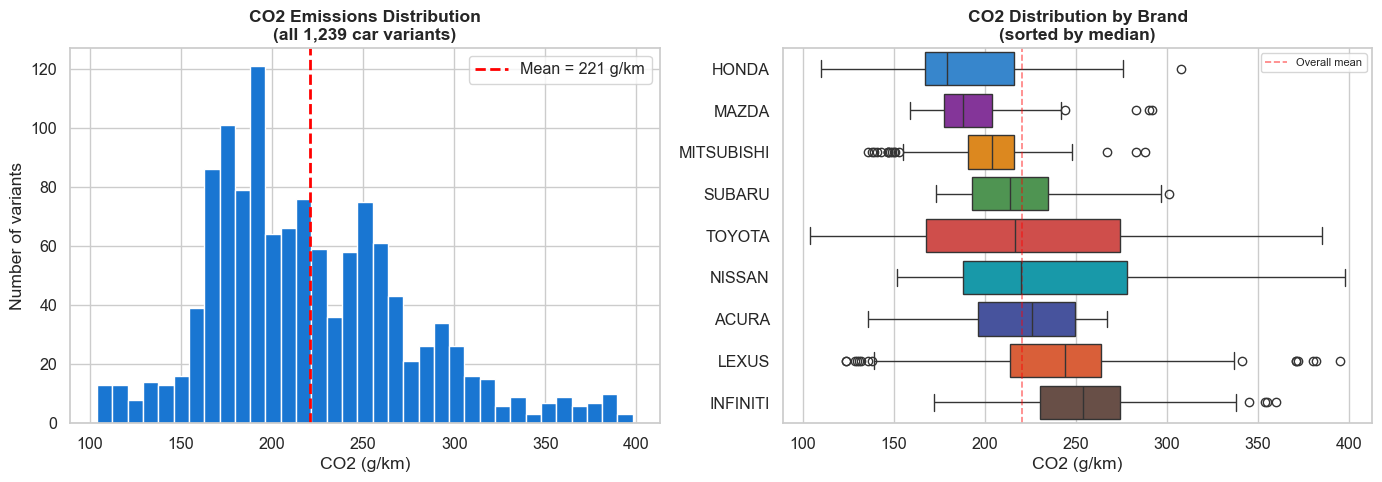

Observations:
  • CO₂ ranges from 104 to 398 g/km — a very wide spread
  • Mean = 221 g/km, but the distribution is right-skewed (pulled by trucks/SUVs)
  • HONDA and MITSUBISHI are the cleanest brands (lowest median)
  • LEXUS shows the widest spread — they make both hybrids AND V8 luxury SUVs
  • TOYOTA median is low thanks to its strong Prius/Hybrid lineup


In [12]:
# ── Cell 8: CO₂ distribution + by brand ──────────────────────────────────────

# Consistent brand colour palette used in all charts
BRAND_COLORS = {
    'ACURA':      '#3949AB',
    'HONDA':      '#1E88E5',
    'INFINITI':   '#6D4C41',
    'LEXUS':      '#F4511E',
    'MAZDA':      '#8E24AA',
    'MITSUBISHI': '#FB8C00',
    'NISSAN':     '#00ACC1',
    'SUBARU':     '#43A047',
    'TOYOTA':     '#E53935',
}

mean_co2 = df['CO2 Emissions(g/km)'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram — all 1239 rows
df['CO2 Emissions(g/km)'].hist(bins=35, ax=axes[0], color='#1976D2', edgecolor='white')
axes[0].axvline(mean_co2, color='red', ls='--', lw=2,
                label=f'Mean = {mean_co2:.0f} g/km')
axes[0].set_title('CO2 Emissions Distribution\n(all 1,239 car variants)', fontweight='bold')
axes[0].set_xlabel('CO2 (g/km)'); axes[0].set_ylabel('Number of variants')
axes[0].legend()

# Boxplot by brand, sorted by median
brand_order = df.groupby('Make')['CO2 Emissions(g/km)'].median().sort_values().index
palette_brands = [BRAND_COLORS[b] for b in brand_order]
sns.boxplot(data=df, y='Make', x='CO2 Emissions(g/km)',
            order=brand_order, ax=axes[1], palette=palette_brands)
axes[1].axvline(mean_co2, color='red', ls='--', lw=1.2, alpha=0.5, label='Overall mean')
axes[1].set_title('CO2 Distribution by Brand\n(sorted by median)', fontweight='bold')
axes[1].set_xlabel('CO2 (g/km)'); axes[1].set_ylabel('')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print('Observations:')
print(f'  • CO₂ ranges from 104 to 398 g/km — a very wide spread')
print(f'  • Mean = {mean_co2:.0f} g/km, but the distribution is right-skewed (pulled by trucks/SUVs)')
print(f'  • HONDA and MITSUBISHI are the cleanest brands (lowest median)')
print(f'  • LEXUS shows the widest spread — they make both hybrids AND V8 luxury SUVs')
print(f'  • TOYOTA median is low thanks to its strong Prius/Hybrid lineup')

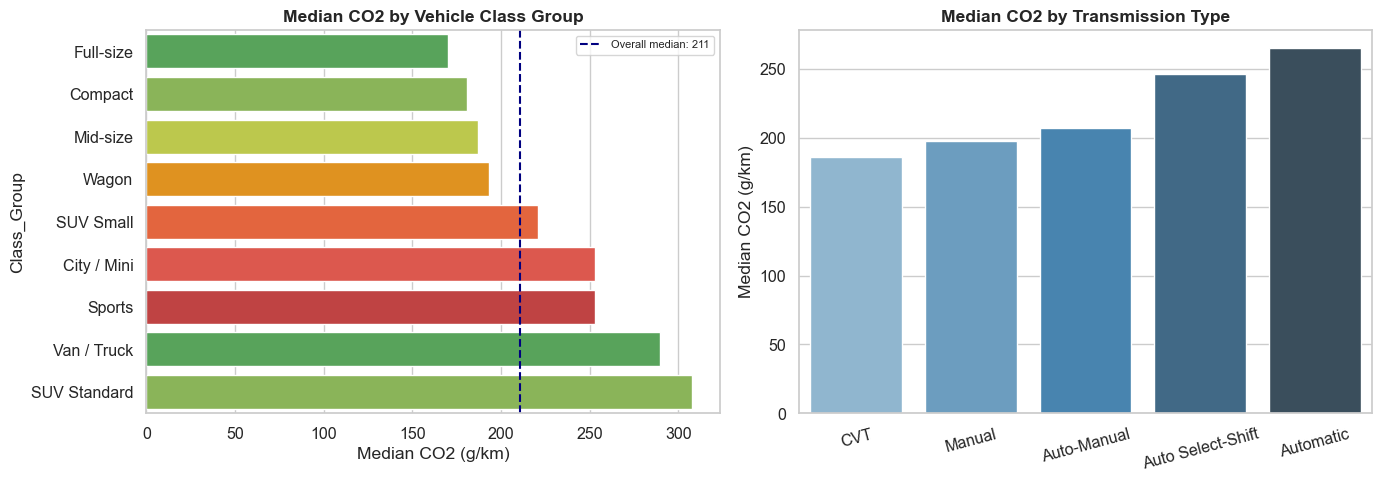

Observations:
  • City/Mini cars are ~160 g/km — Vans & Trucks are ~320 g/km: a 2× difference!
  • CVT (Continuously Variable Transmission) achieves the LOWEST CO₂ of all trans. types
    because it keeps the engine at optimal RPM at all times — no gear shift steps
  • Manual is surprisingly close to Auto Select-Shift — depends on the car, not just gears


In [15]:
# ── Cell 9: CO₂ by Vehicle Class and Fuel Type ────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CO₂ by class group (ordered cleanest to dirtiest)
class_order = df.groupby('Class_Group')['CO2 Emissions(g/km)'].median().sort_values().index
palette_cls = ['#4CAF50','#8BC34A','#CDDC39','#FF9800','#FF5722','#F44336','#D32F2F']
sns.barplot(data=df, y='Class_Group', x='CO2 Emissions(g/km)',
            order=class_order, ax=axes[0],
            palette=palette_cls[:len(class_order)],
            estimator=np.median, ci=None)
axes[0].axvline(df['CO2 Emissions(g/km)'].median(), color='navy',
                ls='--', lw=1.5, label=f'Overall median: {df["CO2 Emissions(g/km)"].median():.0f}')
axes[0].set_title('Median CO2 by Vehicle Class Group', fontweight='bold')
axes[0].set_xlabel('Median CO2 (g/km)'); axes[0].legend(fontsize=8)

# CO₂ by transmission type
trans_order = df.groupby('Trans_Type')['CO2 Emissions(g/km)'].median().sort_values().index
sns.barplot(data=df, x='Trans_Type', y='CO2 Emissions(g/km)',
            order=trans_order, ax=axes[1], palette='Blues_d',
            estimator=np.median, ci=None)
axes[1].set_title('Median CO2 by Transmission Type', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('Median CO2 (g/km)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print('Observations:')
print('  • City/Mini cars are ~160 g/km — Vans & Trucks are ~320 g/km: a 2× difference!')
print('  • CVT (Continuously Variable Transmission) achieves the LOWEST CO₂ of all trans. types')
print('    because it keeps the engine at optimal RPM at all times — no gear shift steps')
print('  • Manual is surprisingly close to Auto Select-Shift — depends on the car, not just gears')

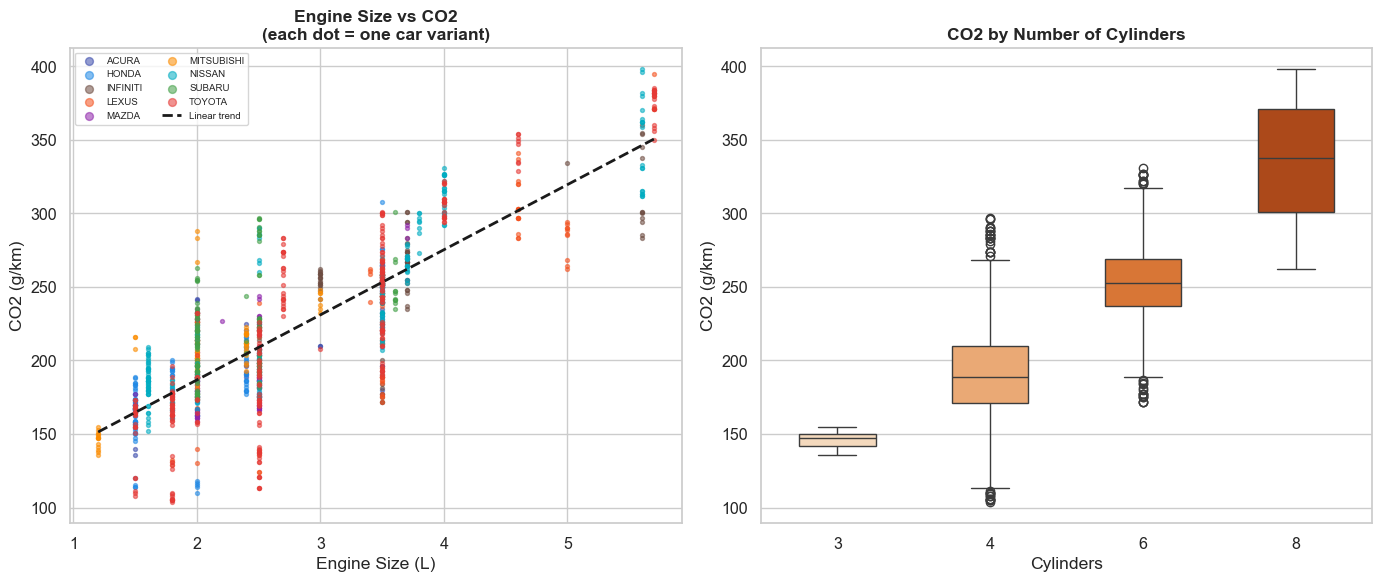

Correlation Engine Size ↔ CO₂: r = 0.835
  • Very strong positive link — every extra litre of displacement ≈ +40-50 g/km CO₂
  • BUT the 4-cylinder group has huge variance: hybrids (104 g/km) → sports (250+ g/km)
  • 8-cylinder = consistently high CO2 — no exceptions in this dataset


In [17]:
# ── Cell 10: Engine Size vs CO₂ — our top 2 priorities ───────────────────────
# This is the most important scatter plot in this notebook:
# it directly shows the relationship between Priority 1 and Priority 2.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter coloured by brand
for brand, color in BRAND_COLORS.items():
    sub = df[df['Make'] == brand]
    axes[0].scatter(sub['Engine Size(L)'], sub['CO2 Emissions(g/km)'],
                    color=color, label=brand, s=8, alpha=0.55)

# Trend line
z = np.polyfit(df['Engine Size(L)'], df['CO2 Emissions(g/km)'], 1)
xr = np.linspace(df['Engine Size(L)'].min(), df['Engine Size(L)'].max(), 200)
axes[0].plot(xr, np.poly1d(z)(xr), 'k--', lw=2, label='Linear trend')
axes[0].set_title('Engine Size vs CO2\n(each dot = one car variant)', fontweight='bold')
axes[0].set_xlabel('Engine Size (L)'); axes[0].set_ylabel('CO2 (g/km)')
axes[0].legend(fontsize=7, ncol=2, markerscale=2)

# Boxplot by cylinder count
cyl_order = sorted(df['Cylinders'].unique())
sns.boxplot(data=df, x='Cylinders', y='CO2 Emissions(g/km)',
            order=cyl_order, ax=axes[1], palette='Oranges', width=0.5)
axes[1].set_title('CO2 by Number of Cylinders', fontweight='bold')
axes[1].set_xlabel('Cylinders'); axes[1].set_ylabel('CO2 (g/km)')

plt.tight_layout()
plt.show()

r_eng_co2 = df['Engine Size(L)'].corr(df['CO2 Emissions(g/km)'])
print(f'Correlation Engine Size ↔ CO₂: r = {r_eng_co2:.3f}')
print('  • Very strong positive link — every extra litre of displacement ≈ +40-50 g/km CO₂')
print('  • BUT the 4-cylinder group has huge variance: hybrids (104 g/km) → sports (250+ g/km)')
print('  • 8-cylinder = consistently high CO2 — no exceptions in this dataset')

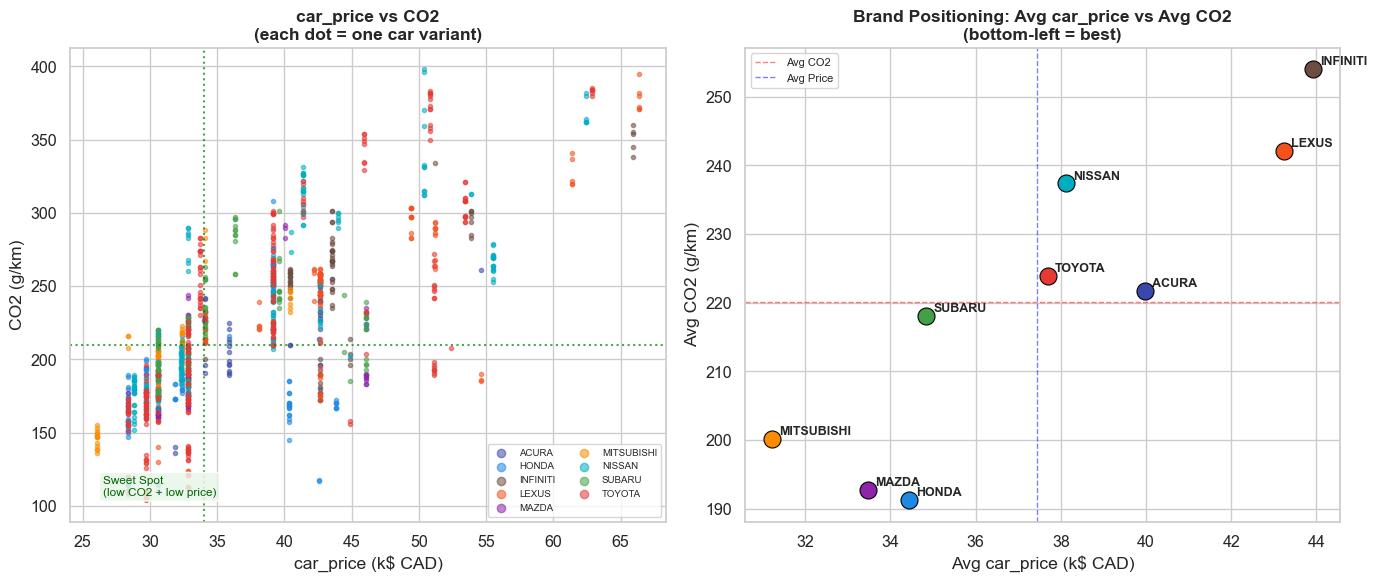

Observations:
  • MITSUBISHI sits in the sweet spot: lowest average price AND relatively low CO₂
  • HONDA: affordable and clean — great balance for volume strategy
  • INFINITI and LEXUS are the most expensive with mixed CO₂ results
  • TOYOTA: mid-price but very low CO₂ thanks to Prius/Hybrid dominance


In [45]:
# ── Cell 11: car_price vs CO₂ — the core business trade-off ──────────────────
# Our goal: find cars that are BOTH low CO₂ AND low price.
# The bottom-left of this scatter = the sweet spot.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# All variants scatter
for brand, color in BRAND_COLORS.items():
    sub = df[df['Make'] == brand]
    axes[0].scatter(sub['car_price'] / 1000, sub['CO2 Emissions(g/km)'],
                    color=color, label=brand, s=9, alpha=0.55)

axes[0].axhline(210, color='green', ls=':', lw=1.5, alpha=0.7)
axes[0].axvline(34, color='green', ls=':', lw=1.5, alpha=0.7)
axes[0].text(26.5, 107, 'Sweet Spot\n(low CO2 + low price)',
             fontsize=8.5, color='darkgreen',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#E8F5E9', alpha=0.85))
axes[0].set_title('car_price vs CO2\n(each dot = one car variant)', fontweight='bold')
axes[0].set_xlabel('car_price (k$ CAD)'); axes[0].set_ylabel('CO2 (g/km)')
axes[0].legend(fontsize=7, ncol=2, markerscale=2)

# Brand-level averages (9 labelled dots)
brand_avg = df.groupby('Make').agg(
    Avg_CO2   = ('CO2 Emissions(g/km)', 'mean'),
    Avg_Price = ('car_price', 'mean')
).reset_index()

for _, row in brand_avg.iterrows():
    c = BRAND_COLORS.get(row['Make'], '#9E9E9E')
    axes[1].scatter(row['Avg_Price']/1000, row['Avg_CO2'],
                    color=c, s=150, edgecolors='black', lw=0.8, zorder=4)
    axes[1].annotate(row['Make'], (row['Avg_Price']/1000, row['Avg_CO2']),
                     textcoords='offset points', xytext=(5, 3), fontsize=9, fontweight='bold')

axes[1].axhline(brand_avg['Avg_CO2'].mean(), color='red', ls='--',
                lw=1, alpha=0.5, label='Avg CO2')
axes[1].axvline(brand_avg['Avg_Price'].mean()/1000, color='blue', ls='--',
                lw=1, alpha=0.5, label='Avg Price')
axes[1].set_title('Brand Positioning: Avg car_price vs Avg CO2\n(bottom-left = best)', fontweight='bold')
axes[1].set_xlabel('Avg car_price (k$ CAD)'); axes[1].set_ylabel('Avg CO2 (g/km)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print('Observations:')
print('  • MITSUBISHI sits in the sweet spot: lowest average price AND relatively low CO₂')
print('  • HONDA: affordable and clean — great balance for volume strategy')
print('  • INFINITI and LEXUS are the most expensive with mixed CO₂ results')
print('  • TOYOTA: mid-price but very low CO₂ thanks to Prius/Hybrid dominance')

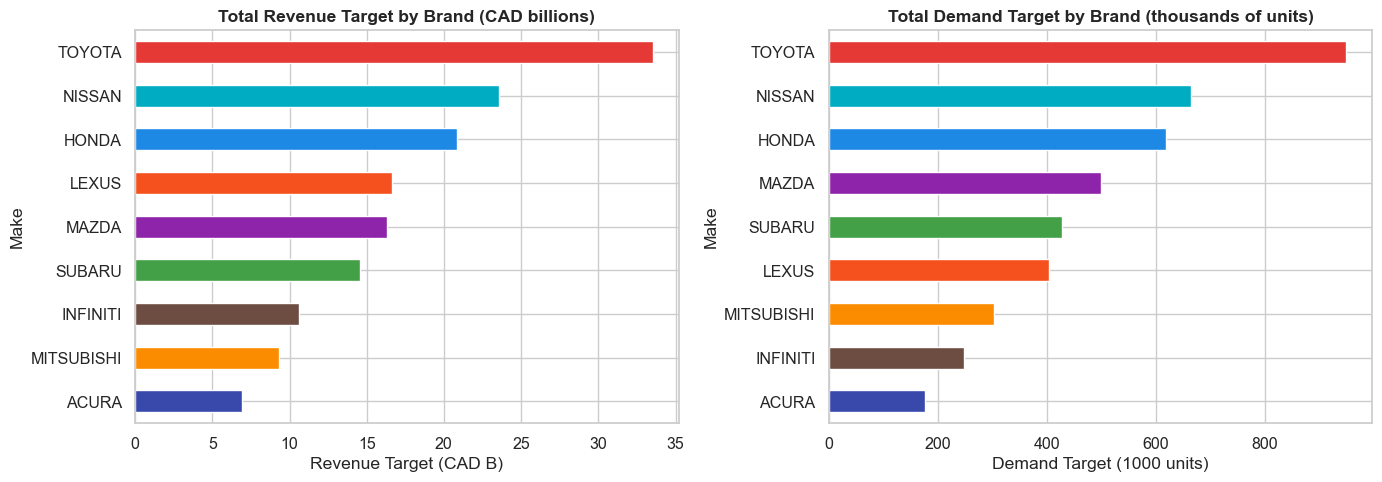

Observations:
  • TOYOTA leads BOTH revenue AND demand — the market leader in this dataset
  • NISSAN has high demand but lower revenue → lower car_price per unit
  • ACURA has very low demand volume but high car_price — niche premium positioning
  • HONDA: strong volume with good revenue — the mass-market sweet spot


In [46]:
# ── Cell 12: Revenue & Demand analysis ────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total revenue target by brand
rev_brand = df.groupby('Make')['revenue_target'].sum().sort_values(ascending=True) / 1e9
rev_colors = [BRAND_COLORS.get(b, '#9E9E9E') for b in rev_brand.index]
rev_brand.plot(kind='barh', ax=axes[0], color=rev_colors, edgecolor='white')
axes[0].set_title('Total Revenue Target by Brand (CAD billions)', fontweight='bold')
axes[0].set_xlabel('Revenue Target (CAD B)')

# Total demand target by brand
dem_brand = df.groupby('Make')['demand_target'].sum().sort_values(ascending=True) / 1000
dem_colors = [BRAND_COLORS.get(b, '#9E9E9E') for b in dem_brand.index]
dem_brand.plot(kind='barh', ax=axes[1], color=dem_colors, edgecolor='white')
axes[1].set_title('Total Demand Target by Brand (thousands of units)', fontweight='bold')
axes[1].set_xlabel('Demand Target (1000 units)')

plt.tight_layout()
plt.show()

print('Observations:')
print('  • TOYOTA leads BOTH revenue AND demand — the market leader in this dataset')
print('  • NISSAN has high demand but lower revenue → lower car_price per unit')
print('  • ACURA has very low demand volume but high car_price — niche premium positioning')
print('  • HONDA: strong volume with good revenue — the mass-market sweet spot')

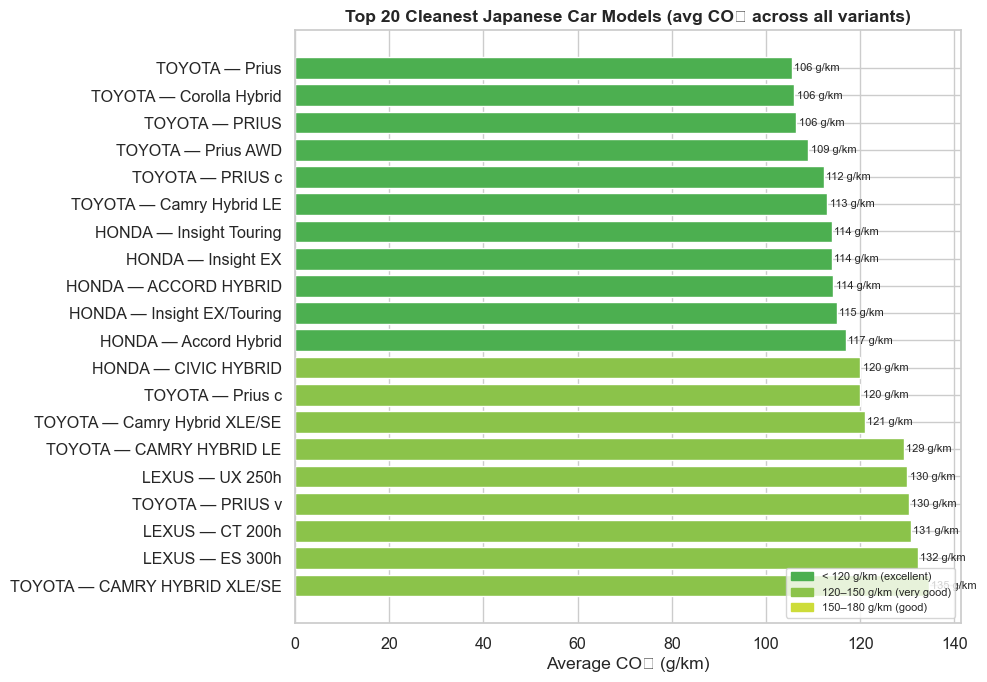

Observations:
  • TOYOTA Prius and Corolla Hybrid lead at ~105–106 g/km — over 2× cleaner than average
  • HONDA Insight and Accord Hybrid right behind at 114–117 g/km
  • All top-20 cleanest models are HYBRIDS — confirms HEV is the key technology to prioritise


In [21]:
# ── Cell 13: Top 20 cleanest individual models ────────────────────────────────

# Average CO₂, engine size and price per model (across all variants)
model_avg = (
    df.groupby(['Make','Model'])
    .agg(
        CO2_mean     = ('CO2 Emissions(g/km)', 'mean'),
        Engine_mean  = ('Engine Size(L)', 'mean'),
        Price_mean   = ('car_price', 'mean'),
        Variants     = ('CO2 Emissions(g/km)', 'count'),
    )
    .reset_index()
    .sort_values('CO2_mean')
    .reset_index(drop=True)
)

top20 = model_avg.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = ['#4CAF50' if v < 120 else '#8BC34A' if v < 150 else '#CDDC39'
              for v in top20['CO2_mean']]
bars = ax.barh(top20['Make'] + ' — ' + top20['Model'],
               top20['CO2_mean'], color=bar_colors, edgecolor='white')
for bar, val in zip(bars, top20['CO2_mean']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f} g/km', va='center', fontsize=8)
ax.set_title('Top 20 Cleanest Japanese Car Models (avg CO₂ across all variants)',
             fontweight='bold')
ax.set_xlabel('Average CO₂ (g/km)')
ax.invert_yaxis()

# Legend
handles = [
    mpatches.Patch(color='#4CAF50', label='< 120 g/km (excellent)'),
    mpatches.Patch(color='#8BC34A', label='120–150 g/km (very good)'),
    mpatches.Patch(color='#CDDC39', label='150–180 g/km (good)'),
]
ax.legend(handles=handles, fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

print('Observations:')
print('  • TOYOTA Prius and Corolla Hybrid lead at ~105–106 g/km — over 2× cleaner than average')
print('  • HONDA Insight and Accord Hybrid right behind at 114–117 g/km')
print('  • All top-20 cleanest models are HYBRIDS — confirms HEV is the key technology to prioritise')

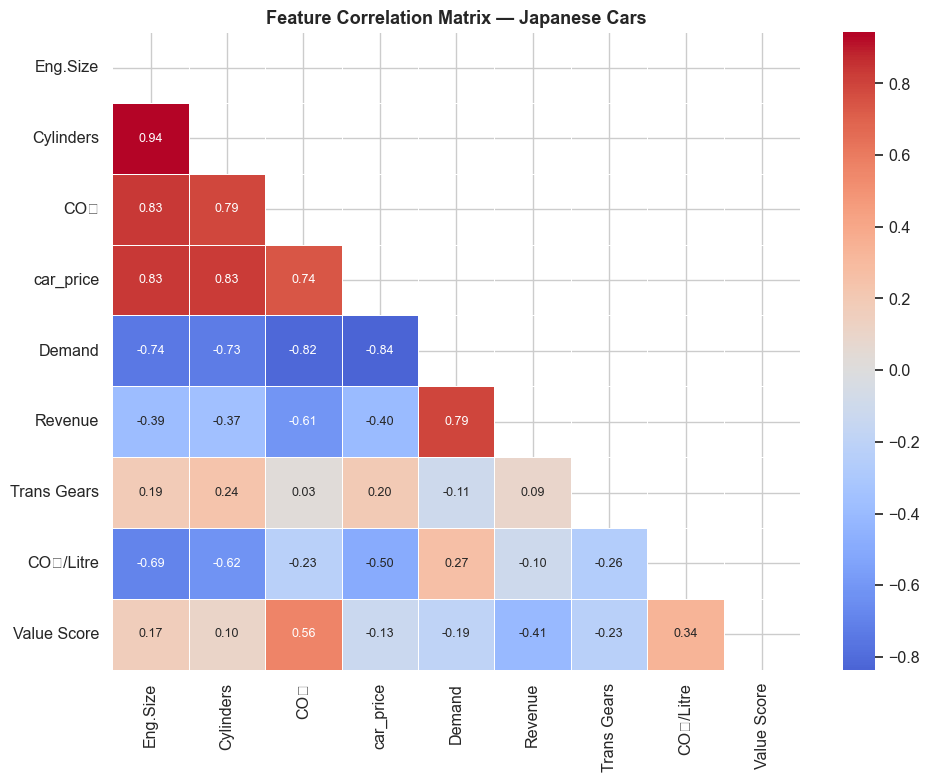

Key correlations with CO₂:
  Eng.Size             r = +0.835  ↑ more CO₂
  Cylinders            r = +0.786  ↑ more CO₂
  car_price            r = +0.736  ↑ more CO₂
  Value Score          r = +0.563  ↑ more CO₂
  Trans Gears          r = +0.026  ~ weak
  CO₂/Litre            r = -0.228  ~ weak
  Revenue              r = -0.609  ↓ less CO₂
  Demand               r = -0.816  ↓ less CO₂


In [22]:
# ── Cell 14: Full Correlation Heatmap ─────────────────────────────────────────
# The Pearson correlation coefficient r measures LINEAR association:
#   r = +1.0 → perfect positive relationship
#   r = -1.0 → perfect negative relationship
#   r =  0.0 → no linear relationship

CORR_COLS = [
    'Engine Size(L)', 'Cylinders', 'CO2 Emissions(g/km)',
    'car_price', 'demand_target', 'revenue_target',
    'Trans_Gears', 'CO2_per_Litre', 'Value_Score'
]
CORR_NAMES = [
    'Eng.Size', 'Cylinders', 'CO₂',
    'car_price', 'Demand', 'Revenue',
    'Trans Gears', 'CO₂/Litre', 'Value Score'
]

corr = (df[CORR_COLS]
        .rename(columns=dict(zip(CORR_COLS, CORR_NAMES)))
        .corr())

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.4,
            ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix — Japanese Cars', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Key correlations with CO₂:')
co2_corr = corr['CO₂'].drop('CO₂').sort_values(ascending=False)
for feat, val in co2_corr.items():
    tag = '↑ more CO₂' if val > 0.5 else ('↓ less CO₂' if val < -0.5 else '~ weak')
    print(f'  {feat:<20} r = {val:+.3f}  {tag}')

---
# ── SECTION 4 — Feature Selection ────────────────────────────────────────────

> With 1,239 rows but only numeric features, feature selection removes **redundant** or **weak** predictors.  
> This prevents overfitting and makes the models more interpretable.  
> I use two complementary methods: statistical (F-score) and model-based (Random Forest).

In [23]:
# ── Cell 15: Define feature matrix and target ─────────────────────────────────

ALL_FEATURES = [
    'Engine Size(L)',
    'Cylinders',
    'car_price',
    'demand_target',
    'revenue_target',
    'Trans_Gears',
    'CO2_per_Litre',
    'Value_Score',
]

TARGET = 'CO2 Emissions(g/km)'

df_ml = df[ALL_FEATURES + [TARGET]].dropna().copy()
X = df_ml[ALL_FEATURES].values
y = df_ml[TARGET].values

print(f'Feature matrix: {X.shape[0]:,} samples × {X.shape[1]} features')
print(f'Target:         {TARGET}')
print(f'Target range:   {y.min():.0f} – {y.max():.0f} g/km')

Feature matrix: 1,053 samples × 8 features
Target:         CO2 Emissions(g/km)
Target range:   113 – 398 g/km


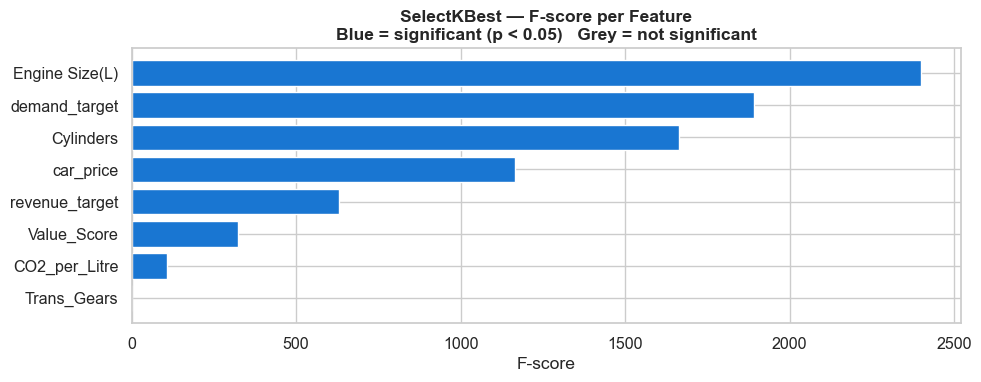

,Feature,F_score,P_value
0,Engine Size(L),2400.884,0.0
3,demand_target,1892.429,0.0
1,Cylinders,1664.660,0.0
2,car_price,1166.668,0.0
4,revenue_target,630.657,0.0
7,Value_Score,322.729,0.0
6,CO2_per_Litre,106.137,0.0
5,Trans_Gears,0.709,0.4


In [24]:
# ── Cell 16: Method 1 — SelectKBest (F-score, univariate test) ────────────────
# F-regression asks: "Is there a statistically significant linear relationship
# between this feature and CO₂?"
# Higher F-score = stronger linear relationship
# p-value < 0.05 = significant at 95% confidence (blue bars)
# p-value > 0.05 = not statistically significant (grey bars)

selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X, y)

fs_df = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'F_score': selector.scores_,
    'P_value': selector.pvalues_
}).sort_values('F_score', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ['#1976D2' if p < 0.05 else '#BDBDBD' for p in fs_df['P_value']]
ax.barh(fs_df['Feature'], fs_df['F_score'], color=bar_colors, edgecolor='white')
ax.set_title('SelectKBest — F-score per Feature\n'
             'Blue = significant (p < 0.05)   Grey = not significant',
             fontweight='bold')
ax.set_xlabel('F-score')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

display(fs_df.round(3))

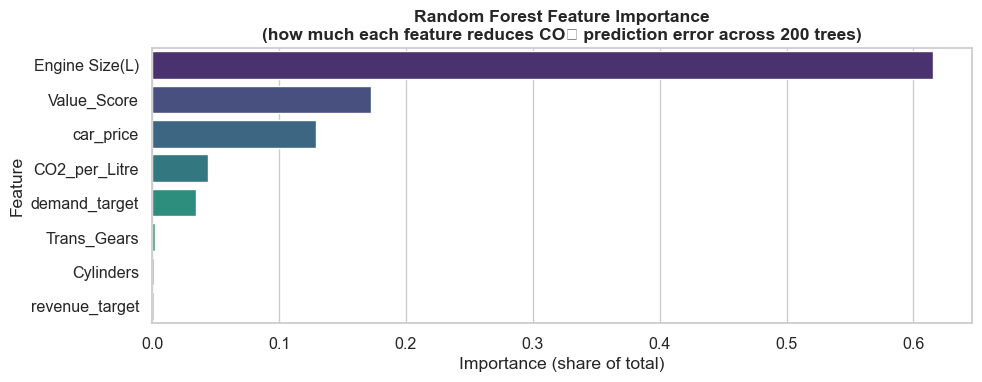

,Feature,Importance
0,Engine Size(L),0.6155
7,Value_Score,0.1726
2,car_price,0.1291
6,CO2_per_Litre,0.0439
3,demand_target,0.0343
5,Trans_Gears,0.0018
1,Cylinders,0.0016
4,revenue_target,0.0013


In [25]:
# ── Cell 17: Method 2 — Random Forest feature importance ─────────────────────
# Random Forest builds 200 trees and measures the average reduction in
# prediction error when each feature is used for a split.
# This captures NON-LINEAR effects that F-score misses.
# e.g. engine size might not have a linear relationship with CO₂
# (because hybrids break the trend), but RF still picks it up.

scaler_sel = StandardScaler()
X_scaled   = scaler_sel.fit_transform(X)

rf_sel = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
rf_sel.fit(X_scaled, y)

rf_imp = pd.DataFrame({
    'Feature':    ALL_FEATURES,
    'Importance': rf_sel.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=rf_imp, y='Feature', x='Importance', ax=ax, palette='viridis')
ax.set_title('Random Forest Feature Importance\n'
             '(how much each feature reduces CO₂ prediction error across 200 trees)',
             fontweight='bold')
ax.set_xlabel('Importance (share of total)')
plt.tight_layout()
plt.show()

display(rf_imp.round(4))

In [26]:
# ── Cell 18: Final feature selection decision ─────────────────────────────────
# I keep features that:
#   a) Rank high in BOTH F-score AND Random Forest importance
#   b) Are not collinear with each other
#   c) Make physical or commercial sense
#
# Dropped:
#   - Cylinders: very collinear with Engine Size (r = 0.94) → redundant
#   - CO2_per_Litre: derived from CO₂ (the target) → risk of data leakage
#   - Value_Score: derived from CO₂ and car_price → also leakage risk

SELECTED_FEATURES = [
    'Engine Size(L)',   # Priority 2 — our key size/efficiency feature
    'car_price',        # Priority 3 — commercial viability
    'demand_target',    # Market demand context
    'revenue_target',   # Commercial scale
    'Trans_Gears',      # Proxy for transmission modernity
]

DROPPED = [f for f in ALL_FEATURES if f not in SELECTED_FEATURES]

print('✅ Selected features:')
for f in SELECTED_FEATURES: print(f'   → {f}')
print()
print('❌ Dropped features:')
for f in DROPPED: print(f'   ✗ {f}')
print()
print('Justification:')
print('  Cylinders    → r=0.94 with Engine Size: completely redundant')
print('  CO2_per_Litre→ uses CO₂ (the target) in its formula → data leakage')
print('  Value_Score  → uses CO₂ in its formula → data leakage')

✅ Selected features:
   → Engine Size(L)
   → car_price
   → demand_target
   → revenue_target
   → Trans_Gears

❌ Dropped features:
   ✗ Cylinders
   ✗ CO2_per_Litre
   ✗ Value_Score

Justification:
  Cylinders    → r=0.94 with Engine Size: completely redundant
  CO2_per_Litre→ uses CO₂ (the target) in its formula → data leakage
  Value_Score  → uses CO₂ in its formula → data leakage


---
# ── SECTION 5 — K-Means Clustering ──────────────────────────────────────────

> K-Means groups similar cars together **without being told what the groups are**.  
> This lets us discover the **natural archetypes** in the Japanese car market:  
> eco cars, family cars, sports cars, premium cars.  
> Once clustered, we can identify which group is most attractive for our strategy.

In [27]:
# ── Cell 19: Prepare clustering matrix ────────────────────────────────────────
# K-Means computes Euclidean DISTANCE between cars.
# Without scaling, car_price (26,000–66,000) would dominate
# Engine Size (1.2–5.7) — the distance would be almost entirely about price.
# → We use StandardScaler: every feature becomes mean=0, std=1.

CLUSTER_COLS = [
    'Engine Size(L)',
    'CO2 Emissions(g/km)',
    'car_price',
    'demand_target',
    'Trans_Gears',
]

df_cl = df[CLUSTER_COLS + ['Make','Model','Vehicle Class',
                            'Fuel_Label','Trans_Type']].dropna().copy()
X_cl  = df_cl[CLUSTER_COLS].values

scaler_cl = StandardScaler()
X_cl_s    = scaler_cl.fit_transform(X_cl)

print(f'Clustering {len(df_cl):,} car variants on {len(CLUSTER_COLS)} features')
print('\nAfter StandardScaler (should be ~0 mean, ~1 std):')
print(pd.DataFrame(X_cl_s, columns=CLUSTER_COLS)
      .describe().loc[['mean','std']].round(2))

Clustering 1,053 car variants on 5 features

After StandardScaler (should be ~0 mean, ~1 std):
      Engine Size(L)  CO2 Emissions(g/km)  car_price  demand_target  \
mean            -0.0                  0.0        0.0           -0.0   
std              1.0                  1.0        1.0            1.0   

      Trans_Gears  
mean          0.0  
std           1.0  


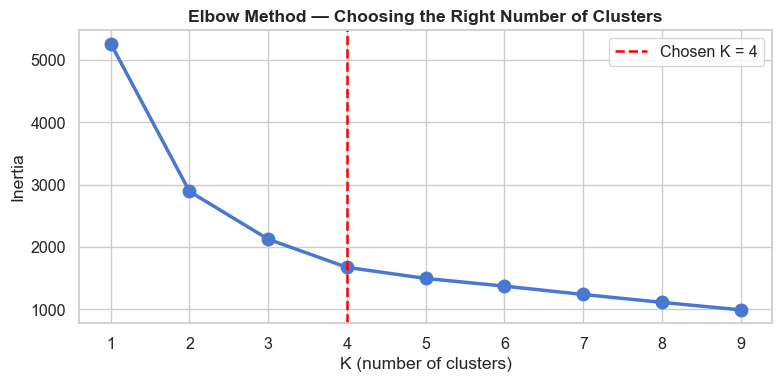

📌 We choose K = 4 because:
  • Inertia drops steeply from K=1 to K=4, then flattens — this is the elbow
  • K=4 maps to 4 intuitive market segments we can explain to stakeholders:
    🟢 Eco  |  🚗 Family  |  🏎️  Sport  |  💎 Premium


In [28]:
# ── Cell 20: Elbow method — find optimal K ────────────────────────────────────
# We test K = 1 to 9 clusters.
# Inertia = sum of squared distances of each point to its cluster centre.
# Lower inertia = tighter, better-defined clusters.
# We pick the K at the 'elbow' — where adding more clusters gives little benefit.

inertias = []
K_RANGE  = range(1, 10)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_cl_s)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_RANGE, inertias, 'bo-', lw=2.5, ms=9)
ax.axvline(4, color='red', ls='--', lw=1.8, label='Chosen K = 4')
ax.set_title('Elbow Method — Choosing the Right Number of Clusters', fontweight='bold')
ax.set_xlabel('K (number of clusters)'); ax.set_ylabel('Inertia')
ax.set_xticks(list(K_RANGE))
ax.legend()
plt.tight_layout()
plt.show()

print('📌 We choose K = 4 because:')
print('  • Inertia drops steeply from K=1 to K=4, then flattens — this is the elbow')
print('  • K=4 maps to 4 intuitive market segments we can explain to stakeholders:')
print('    🟢 Eco  |  🚗 Family  |  🏎️  Sport  |  💎 Premium')

In [29]:
# ── Cell 21: Run K-Means and profile the clusters ─────────────────────────────

K_OPT  = 4
kmeans = KMeans(n_clusters=K_OPT, random_state=RANDOM_STATE, n_init=10)
df_cl['Cluster'] = kmeans.fit_predict(X_cl_s)

# Profile: what is the average of each feature per cluster?
profile = df_cl.groupby('Cluster')[CLUSTER_COLS].mean().round(1)
print('Cluster profiles (mean values):')
display(profile)

# Auto-label clusters based on their dominant characteristics
CLUSTER_NAMES = {}
for c in range(K_OPT):
    r = profile.loc[c]
    if r['CO2 Emissions(g/km)'] < 160:
        CLUSTER_NAMES[c] = '🟢 Eco / Hybrid'
    elif r['car_price'] > 47000:
        CLUSTER_NAMES[c] = '💎 Premium / Luxury'
    elif r['Engine Size(L)'] > 3.5:
        CLUSTER_NAMES[c] = '🏎️  Sport / Large'
    else:
        CLUSTER_NAMES[c] = '🚗 Family / Mainstream'

df_cl['Cluster_Name'] = df_cl['Cluster'].map(CLUSTER_NAMES)

print('\nCluster labels assigned:')
for k, v in CLUSTER_NAMES.items():
    n = (df_cl['Cluster'] == k).sum()
    print(f'  Cluster {k}: {v}  ({n} variants)')

Cluster profiles (mean values):


,Engine Size(L),CO2 Emissions(g/km),car_price,demand_target,Trans_Gears
Cluster,,,,,
0,4.9,322.8,54538.1,1716.5,6.6
1,2.1,190.0,31683.7,4123.9,6.0
2,2.9,217.6,38884.8,3439.9,8.2
3,3.2,255.5,41111.3,2783.3,6.0



Cluster labels assigned:
  Cluster 0: 💎 Premium / Luxury  (122 variants)
  Cluster 1: 🚗 Family / Mainstream  (453 variants)
  Cluster 2: 🚗 Family / Mainstream  (168 variants)
  Cluster 3: 🚗 Family / Mainstream  (310 variants)


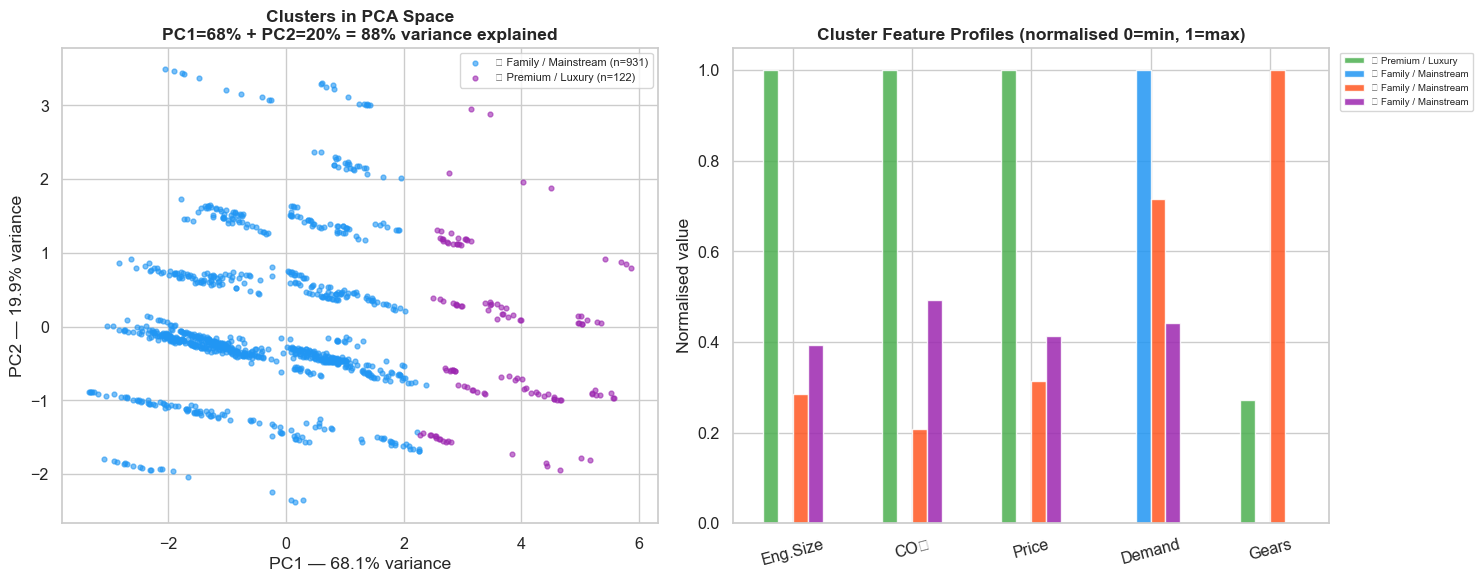

📌 Interpretation:
  🟢 Eco/Hybrid:       Smallest engines, lowest CO₂, moderate price — BEST for green strategy
  🚗 Family/Mainstream: Middle of everything — highest demand volume — BEST for revenue
  🏎️  Sport/Large:      Biggest engines, highest CO₂ — avoid for eco targets
  💎 Premium/Luxury:    Highest price, mixed CO₂ — niche high-margin segment


In [30]:
# ── Cell 22: Visualise clusters with PCA ──────────────────────────────────────
# PCA (Principal Component Analysis) reduces our 5 features to 2 dimensions
# so we can PLOT the clusters in 2D.
# PC1 captures the most variance, PC2 the second most.
# If clusters are well-separated in this 2D view, K=4 is a good choice.

pca   = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cl_s)
df_cl['PC1'] = X_pca[:, 0]
df_cl['PC2'] = X_pca[:, 1]
explained    = pca.explained_variance_ratio_ * 100

CLUSTER_PALETTE = {
    '🟢 Eco / Hybrid':      '#4CAF50',
    '🚗 Family / Mainstream':'#2196F3',
    '🏎️  Sport / Large':    '#FF5722',
    '💎 Premium / Luxury':   '#9C27B0',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# PCA scatter
for name, color in CLUSTER_PALETTE.items():
    mask = df_cl['Cluster_Name'] == name
    if mask.sum() == 0: continue
    axes[0].scatter(df_cl.loc[mask,'PC1'], df_cl.loc[mask,'PC2'],
                    c=color, label=f'{name} (n={mask.sum()})',
                    s=12, alpha=0.6)

axes[0].set_title(f'Clusters in PCA Space\n'
                  f'PC1={explained[0]:.0f}% + PC2={explained[1]:.0f}% = {sum(explained):.0f}% variance explained',
                  fontweight='bold')
axes[0].set_xlabel(f'PC1 — {explained[0]:.1f}% variance')
axes[0].set_ylabel(f'PC2 — {explained[1]:.1f}% variance')
axes[0].legend(fontsize=8)

# Normalised cluster profile bar chart
norm_p = (profile - profile.min()) / (profile.max() - profile.min())
norm_p.index = [CLUSTER_NAMES[i] for i in norm_p.index]
norm_p.columns = ['Eng.Size','CO₂','Price','Demand','Gears']
norm_p.T.plot(kind='bar', ax=axes[1],
              color=list(CLUSTER_PALETTE.values()), edgecolor='white', alpha=0.85)
axes[1].set_title('Cluster Feature Profiles (normalised 0=min, 1=max)', fontweight='bold')
axes[1].set_xticklabels(norm_p.columns, rotation=15)
axes[1].set_ylabel('Normalised value')
axes[1].legend(fontsize=7, bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

print('📌 Interpretation:')
print('  🟢 Eco/Hybrid:       Smallest engines, lowest CO₂, moderate price — BEST for green strategy')
print('  🚗 Family/Mainstream: Middle of everything — highest demand volume — BEST for revenue')
print('  🏎️  Sport/Large:      Biggest engines, highest CO₂ — avoid for eco targets')
print('  💎 Premium/Luxury:    Highest price, mixed CO₂ — niche high-margin segment')

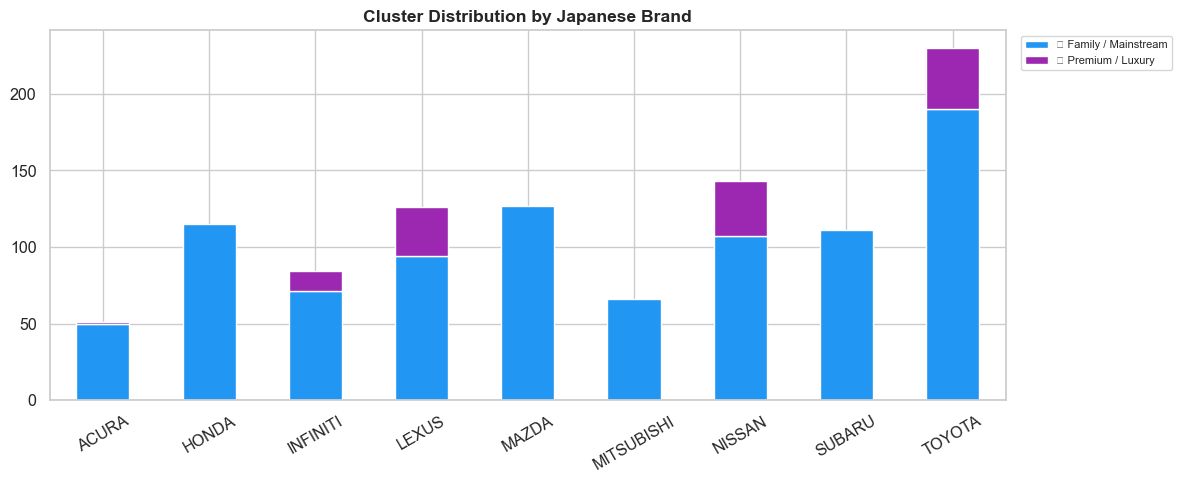

📌 Interpretation:
  • TOYOTA dominates the Eco cluster — driven by Prius, Camry Hybrid, Corolla Hybrid
  • HONDA and MITSUBISHI sit almost entirely in Family/Mainstream — volume focus
  • LEXUS and INFINITI split between Premium and Sport/Large — luxury focus
  • NISSAN is mostly Family/Mainstream but has outliers (GT-R in Sport, Armada in Large)


In [31]:
# ── Cell 23: Cluster composition by brand ─────────────────────────────────────

cluster_brand = (
    df_cl.groupby(['Make','Cluster_Name'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 5))
# Order columns for consistent colour
col_order = [c for c in CLUSTER_PALETTE.keys() if c in cluster_brand.columns]
cluster_brand[col_order].plot(
    kind='bar', ax=ax, stacked=True,
    color=[CLUSTER_PALETTE[c] for c in col_order],
    edgecolor='white'
)
ax.set_title('Cluster Distribution by Japanese Brand', fontweight='bold')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

print('📌 Interpretation:')
print('  • TOYOTA dominates the Eco cluster — driven by Prius, Camry Hybrid, Corolla Hybrid')
print('  • HONDA and MITSUBISHI sit almost entirely in Family/Mainstream — volume focus')
print('  • LEXUS and INFINITI split between Premium and Sport/Large — luxury focus')
print('  • NISSAN is mostly Family/Mainstream but has outliers (GT-R in Sport, Armada in Large)')

---
# ── SECTION 6 — Regression Models ────────────────────────────────────────────

> Regression quantifies **how much each feature drives CO₂ emissions**.  
> This tells us which variables to target when recommending low-CO₂ cars.  
> I compare 3 models: Linear (interpretable), Random Forest, and Gradient Boosting.

In [32]:
# ── Cell 24: Train/test split ─────────────────────────────────────────────────
# We use 80% of data for training, 20% for testing.
# The test set is data the model has NEVER seen — this is how we measure
# real performance (not just "has the model memorised the training data?")

df_reg = df[SELECTED_FEATURES + [TARGET]].dropna().copy()
X_reg  = df_reg[SELECTED_FEATURES].values
y_reg  = df_reg[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

# Scale features: always fit scaler on TRAINING data only,
# then apply to test data — this prevents data leakage!
scaler_reg = StandardScaler()
X_train_s  = scaler_reg.fit_transform(X_train)
X_test_s   = scaler_reg.transform(X_test)

print(f'Training set: {len(X_train):,} samples')
print(f'Test set:     {len(X_test):,} samples')
print(f'Features:     {SELECTED_FEATURES}')

Training set: 842 samples
Test set:     211 samples
Features:     ['Engine Size(L)', 'car_price', 'demand_target', 'revenue_target', 'Trans_Gears']


In [33]:
# ── Cell 25: Train 3 regression models ────────────────────────────────────────
# 1. Linear Regression — simplest model, coefficients are directly interpretable
# 2. Random Forest — captures non-linear effects, robust to outliers
# 3. Gradient Boosting — usually most accurate for tabular data
#
# Metrics:
#   R² (coefficient of determination): 0 = no better than predicting the mean;
#                                       1 = perfect prediction
#   RMSE (Root Mean Squared Error): average error in g/km — same unit as CO₂
#   CV R²: cross-validation R² — more reliable because tested on 5 different splits

MODELS = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(
                             n_estimators=200, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingRegressor(
                             n_estimators=200, random_state=RANDOM_STATE),
}

results = {}
for name, model in MODELS.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    r2     = r2_score(y_test, y_pred)
    cv_r2  = cross_val_score(model, X_train_s, y_train, cv=5, scoring='r2').mean()
    results[name] = {'RMSE (g/km)': rmse, 'R²': r2, 'CV R²': cv_r2}
    print(f'  {name:<25}  RMSE={rmse:.1f}  R²={r2:.3f}  CV R²={cv_r2:.3f}')

print()
print('📌 Interpretation:')
print('  R² close to 1.0 = model explains almost all variance in CO₂')
print('  RMSE in g/km = average prediction error — lower is better')
print('  CV R² is the most honest metric — averaged across 5 separate test sets')

  Linear Regression          RMSE=23.7  R²=0.803  CV R²=0.795
  Random Forest              RMSE=18.6  R²=0.879  CV R²=0.869
  Gradient Boosting          RMSE=16.5  R²=0.904  CV R²=0.871

📌 Interpretation:
  R² close to 1.0 = model explains almost all variance in CO₂
  RMSE in g/km = average prediction error — lower is better
  CV R² is the most honest metric — averaged across 5 separate test sets


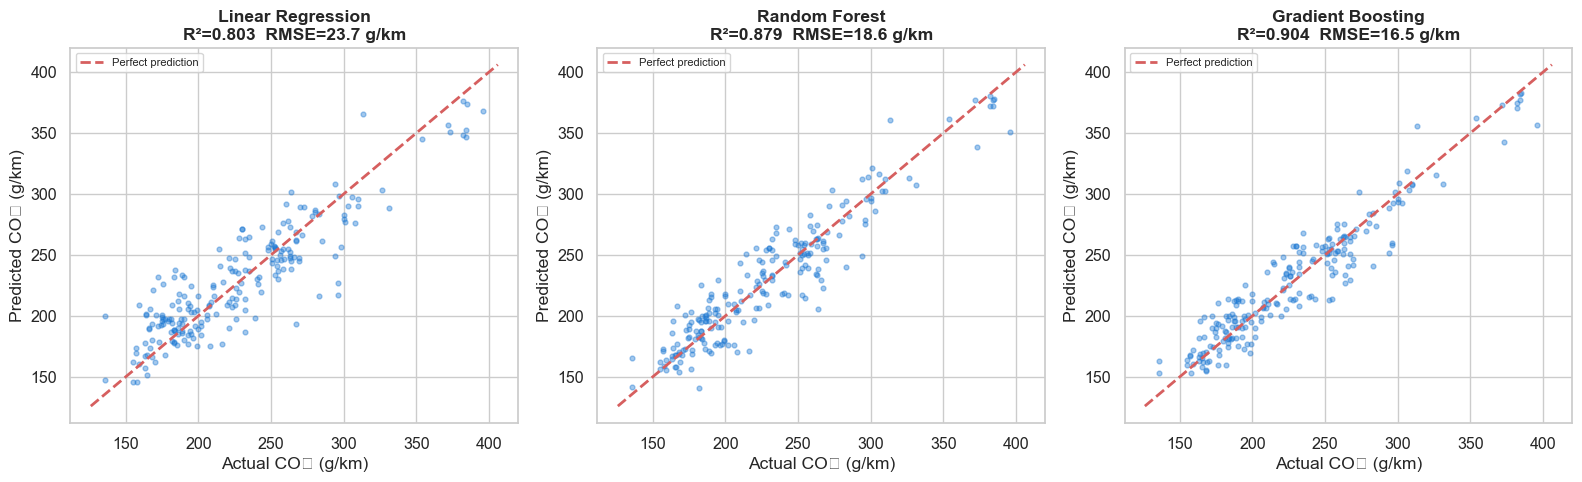

In [34]:
# ── Cell 26: Visualise predictions (actual vs predicted) ─────────────────────
# A perfect model would have all dots on the red diagonal line.
# Scatter above the line = model under-predicted CO₂.
# Scatter below the line = model over-predicted CO₂.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, model) in zip(axes, MODELS.items()):
    y_pred = model.predict(X_test_s)
    ax.scatter(y_test, y_pred, alpha=0.4, s=12, color='#1976D2')
    lims = [min(y_test.min(), y_pred.min()) - 10,
            max(y_test.max(), y_pred.max()) + 10]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
    r = results[name]
    ax.set_title(f'{name}\nR²={r["R²"]:.3f}  RMSE={r["RMSE (g/km)"]:.1f} g/km',
                 fontweight='bold')
    ax.set_xlabel('Actual CO₂ (g/km)')
    ax.set_ylabel('Predicted CO₂ (g/km)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

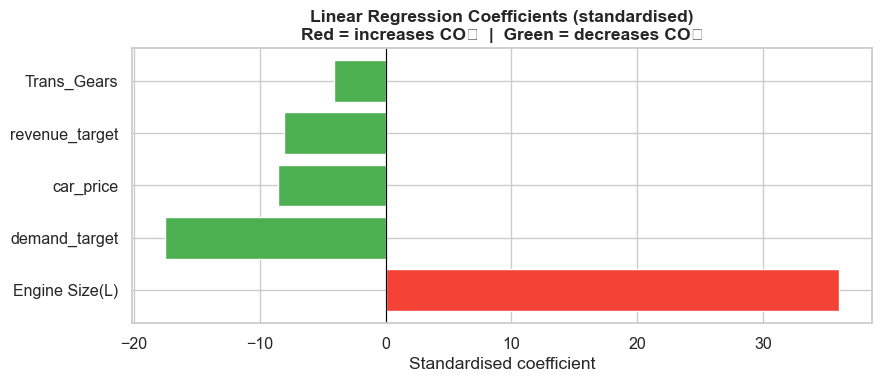

📌 Business interpretation:
  Engine Size(L)          INCREASES CO₂  (coef = +36.00)
  demand_target           DECREASES CO₂  (coef = -17.51)
  car_price               DECREASES CO₂  (coef = -8.53)
  revenue_target          DECREASES CO₂  (coef = -8.11)
  Trans_Gears             DECREASES CO₂  (coef = -4.08)


In [35]:
# ── Cell 27: Linear Regression coefficients — what DRIVES CO₂? ───────────────
# Standardised coefficients are directly comparable:
# a coefficient of +20 means "one standard deviation increase in this feature
# is associated with +20 g/km more CO₂"
# Red bars = increases CO₂ (bad)    Green bars = decreases CO₂ (good)

lr   = MODELS['Linear Regression']
coef = pd.DataFrame({
    'Feature':     SELECTED_FEATURES,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = ['#F44336' if c > 0 else '#4CAF50' for c in coef['Coefficient']]
ax.barh(coef['Feature'], coef['Coefficient'], color=bar_colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Linear Regression Coefficients (standardised)\n'
             'Red = increases CO₂  |  Green = decreases CO₂',
             fontweight='bold')
ax.set_xlabel('Standardised coefficient')
plt.tight_layout()
plt.show()

print('📌 Business interpretation:')
for _, row in coef.iterrows():
    d = 'INCREASES' if row['Coefficient'] > 0 else 'DECREASES'
    print(f'  {row["Feature"]:<22}  {d} CO₂  (coef = {row["Coefficient"]:+.2f})')

---
# ── SECTION 7 — Scoring & Best Japanese Car ──────────────────────────────────

> I now combine all 3 priorities into a **single weighted score** to rank every model.  
> Score formula: **CO₂ (50%) + Engine Size (25%) + car_price (25%)**  
> Higher score = lower CO₂ AND smaller engine AND lower price = BEST car.

In [36]:
# ── Cell 28: Aggregate variants → one row per model ──────────────────────────
# Each model has multiple variants (trims, transmissions).
# We compute the MEAN per model to get a single representative value.
# Mean is appropriate here because each row is an equally-valid variant.

model_scores = (
    df.groupby(['Make','Model'])
    .agg(
        CO2_mean      = ('CO2 Emissions(g/km)', 'mean'),
        Engine_mean   = ('Engine Size(L)',       'mean'),
        Price_mean    = ('car_price',            'mean'),
        Demand_mean   = ('demand_target',        'mean'),
        Revenue_mean  = ('revenue_target',       'mean'),
        Vehicle_Class = ('Vehicle Class',        lambda x: x.mode()[0]),
        Fuel_Label    = ('Fuel_Label',           lambda x: x.mode()[0]),
        Variants      = ('CO2 Emissions(g/km)',  'count'),
    )
    .reset_index()
)

print(f'Models to rank: {len(model_scores)}')
display(model_scores.head(5).round(1))

Models to rank: 384


,Make,Model,CO2_mean,Engine_mean,Price_mean,Demand_mean,Revenue_mean,Vehicle_Class,Fuel_Label,Variants
0,ACURA,ILX,200.3,2.3,35385.7,4018.3,142081800.0,COMPACT,Premium Gasoline,7
1,ACURA,ILX HYBRID,138.0,1.5,31850.0,4617.0,147051450.0,COMPACT,Premium Gasoline,2
2,ACURA,MDX 4WD,255.0,3.5,42650.0,3436.0,146545400.0,SUV - SMALL,Premium Gasoline,1
3,ACURA,MDX HYBRID AWD,210.0,3.0,40400.0,3349.0,135299600.0,SUV - SMALL,Premium Gasoline,1
4,ACURA,MDX Hybrid AWD,210.0,3.0,40400.0,3009.0,121563600.0,SUV - SMALL,Premium Gasoline,1


In [37]:
# ── Cell 29: Build the composite score ────────────────────────────────────────
#
# Step 1: MinMax-normalise CO₂, Engine Size, and Price to [0, 1]
# Step 2: INVERT them — because lower raw value = better car for our goals
#         Score = 1 - normalised_value
#         → a car with CO₂ = 104 g/km (min) gets CO2_score = 1.0 (best)
#         → a car with CO₂ = 398 g/km (max) gets CO2_score = 0.0 (worst)
# Step 3: Weighted average
#
# Weights reflect our stated priorities:
#   CO₂        = 50%  (most important)
#   Engine Size = 25%  (second priority)
#   car_price   = 25%  (third priority)

W_CO2 = 0.50
W_ENG = 0.25
W_PRC = 0.25

mm = MinMaxScaler()
model_scores[['CO2_norm','Eng_norm','Price_norm']] = mm.fit_transform(
    model_scores[['CO2_mean','Engine_mean','Price_mean']]
)

model_scores['CO2_score']    = 1 - model_scores['CO2_norm']
model_scores['Engine_score'] = 1 - model_scores['Eng_norm']
model_scores['Price_score']  = 1 - model_scores['Price_norm']

model_scores['Final_Score'] = (
    W_CO2 * model_scores['CO2_score'] +
    W_ENG * model_scores['Engine_score'] +
    W_PRC * model_scores['Price_score']
)

model_scores = model_scores.sort_values('Final_Score', ascending=False).reset_index(drop=True)
model_scores['Rank'] = model_scores.index + 1

print('Top 15 ranked models:')
display(
    model_scores[['Rank','Make','Model','CO2_mean','Engine_mean',
                  'Price_mean','Final_Score','Vehicle_Class']]
    .head(15)
    .round(2)
)

Top 15 ranked models:


,Rank,Make,Model,CO2_mean,Engine_mean,Price_mean,Final_Score,Vehicle_Class
0,1,TOYOTA,PRIUS c,112.25,1.5,28350.0,0.96,COMPACT
1,2,HONDA,Insight Touring,114.00,1.5,28350.0,0.95,MID-SIZE
2,3,HONDA,Insight EX,114.00,1.5,28350.0,0.95,MID-SIZE
3,4,HONDA,Insight EX/Touring,115.00,1.5,28350.0,0.95,MID-SIZE
4,5,TOYOTA,Prius,105.50,1.8,29700.0,0.94,MID-SIZE
5,6,TOYOTA,Corolla Hybrid,106.00,1.8,29700.0,0.94,COMPACT
6,7,HONDA,CIVIC HYBRID,120.00,1.5,28350.0,0.94,COMPACT
7,8,TOYOTA,Prius c,120.00,1.5,28350.0,0.94,COMPACT
8,9,TOYOTA,PRIUS,106.40,1.8,29700.0,0.94,MID-SIZE
9,10,TOYOTA,Prius AWD,109.00,1.8,29700.0,0.94,MID-SIZE


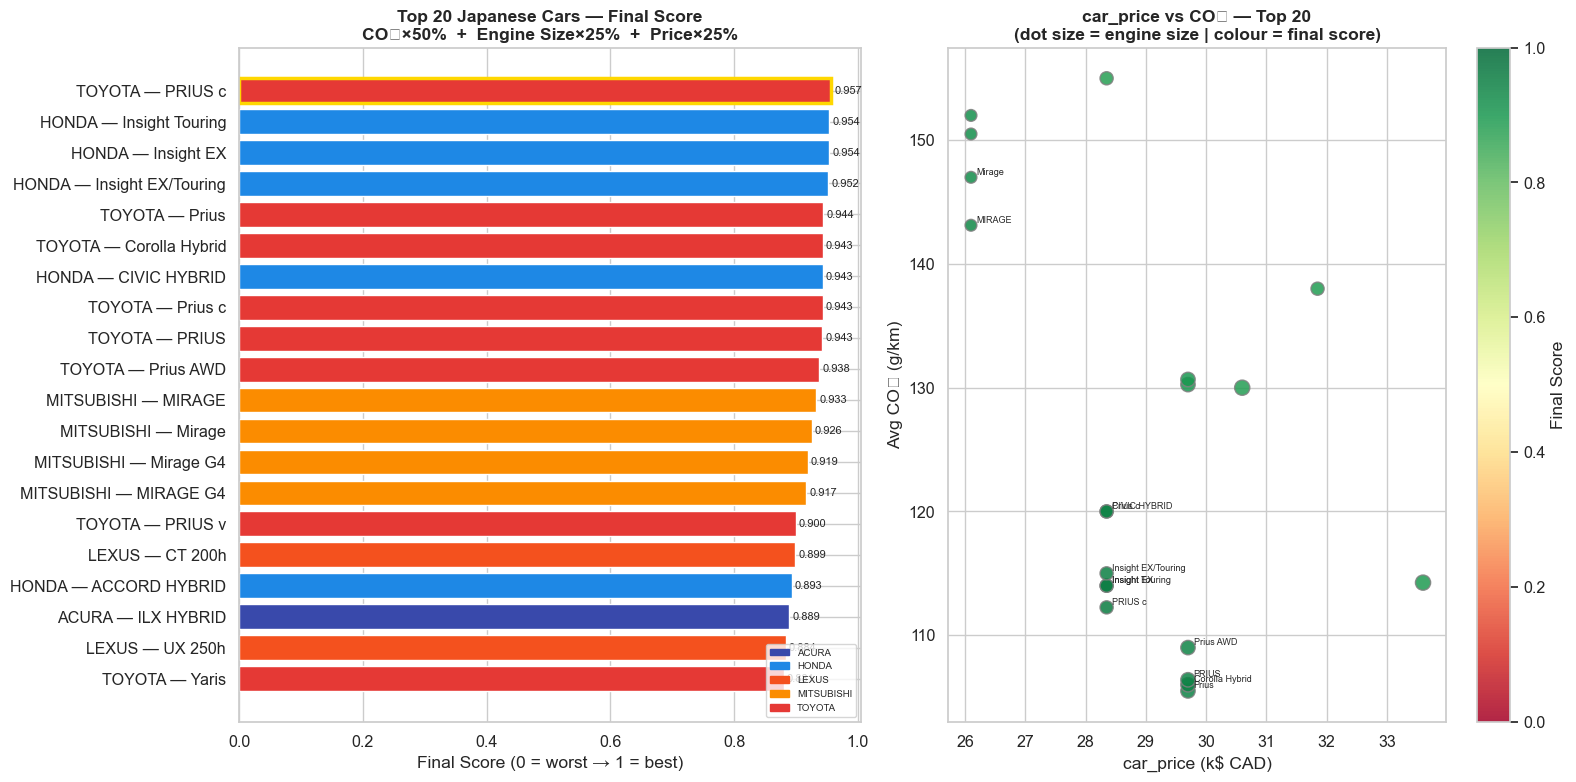

In [38]:
# ── Cell 30: Visualise the ranking — top 20 ───────────────────────────────────

top20 = model_scores.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Bar chart: final score
bar_colors = [BRAND_COLORS.get(m, '#9E9E9E') for m in top20['Make']]
bars = axes[0].barh(
    top20['Make'] + ' — ' + top20['Model'],
    top20['Final_Score'],
    color=bar_colors, edgecolor='white'
)
# Highlight #1 with gold outline
bars[0].set_edgecolor('gold'); bars[0].set_linewidth(2.5)

for bar, score in zip(bars, top20['Final_Score']):
    axes[0].text(bar.get_width() + 0.005,
                 bar.get_y() + bar.get_height()/2,
                 f'{score:.3f}', va='center', fontsize=8)

axes[0].set_title('Top 20 Japanese Cars — Final Score\n'
                  'CO₂×50%  +  Engine Size×25%  +  Price×25%',
                  fontweight='bold')
axes[0].set_xlabel('Final Score (0 = worst → 1 = best)')
axes[0].invert_yaxis()

# Brand legend
legend_handles = [mpatches.Patch(color=c, label=b)
                  for b, c in BRAND_COLORS.items()
                  if b in top20['Make'].values]
axes[0].legend(handles=legend_handles, fontsize=7, loc='lower right')

# Scatter: price vs CO2, size = engine, color = score
sc = axes[1].scatter(
    top20['Price_mean'] / 1000, top20['CO2_mean'],
    s=top20['Engine_mean'] * 60,
    c=top20['Final_Score'], cmap='RdYlGn',
    alpha=0.85, edgecolors='grey', vmin=0, vmax=1
)
plt.colorbar(sc, ax=axes[1], label='Final Score')
for _, row in top20.head(12).iterrows():
    axes[1].annotate(
        row['Model'],
        (row['Price_mean']/1000, row['CO2_mean']),
        textcoords='offset points', xytext=(4, 2), fontsize=6.5
    )
axes[1].set_title('car_price vs CO₂ — Top 20\n(dot size = engine size | colour = final score)',
                  fontweight='bold')
axes[1].set_xlabel('car_price (k$ CAD)'); axes[1].set_ylabel('Avg CO₂ (g/km)')

plt.tight_layout()
plt.show()

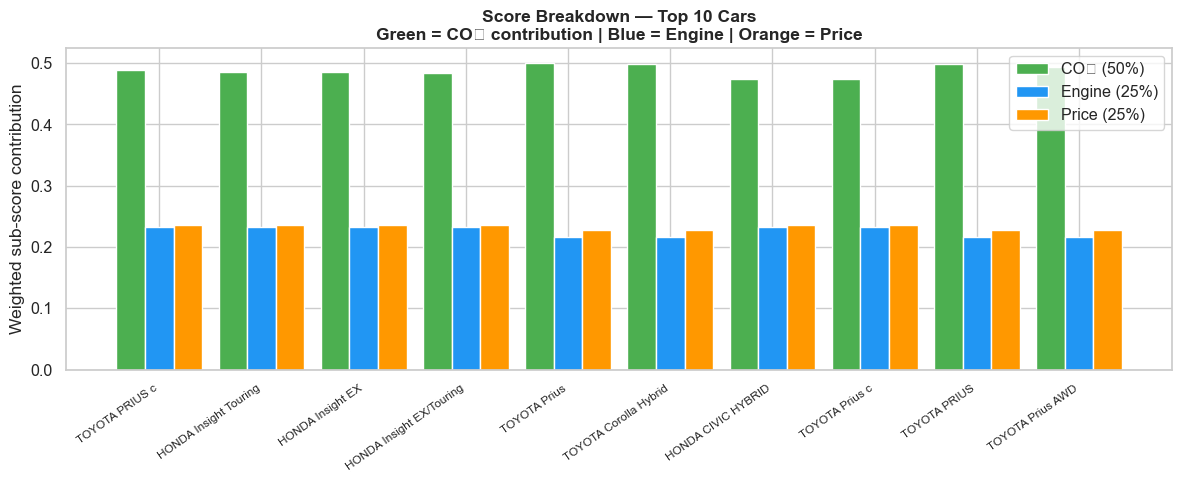

📌 How to read this chart:
  • Taller GREEN bar → car wins mainly because of low CO₂ (our top priority)
  • Taller BLUE bar  → car wins because of a small engine
  • Taller ORANGE bar → car wins because of a low price
  • The best cars have all 3 bars tall — balanced excellence


In [39]:
# ── Cell 31: Score breakdown — what drives each car's score ───────────────────
# This stacked bar shows how much each of the 3 sub-scores contributes
# to the final score for the top 10 cars.

top10 = model_scores.head(10).copy()
top10['Label'] = top10['Make'] + ' ' + top10['Model']

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(top10))
w = 0.28

ax.bar(x - w, top10['CO2_score']    * W_CO2, width=w,
       label=f'CO₂ ({W_CO2*100:.0f}%)',    color='#4CAF50')
ax.bar(x,     top10['Engine_score'] * W_ENG, width=w,
       label=f'Engine ({W_ENG*100:.0f}%)', color='#2196F3')
ax.bar(x + w, top10['Price_score']  * W_PRC, width=w,
       label=f'Price ({W_PRC*100:.0f}%)',  color='#FF9800')

ax.set_xticks(x)
ax.set_xticklabels(top10['Label'], rotation=35, ha='right', fontsize=8.5)
ax.set_title('Score Breakdown — Top 10 Cars\n'
             'Green = CO₂ contribution | Blue = Engine | Orange = Price',
             fontweight='bold')
ax.set_ylabel('Weighted sub-score contribution')
ax.legend()
plt.tight_layout()
plt.show()

print('📌 How to read this chart:')
print('  • Taller GREEN bar → car wins mainly because of low CO₂ (our top priority)')
print('  • Taller BLUE bar  → car wins because of a small engine')
print('  • Taller ORANGE bar → car wins because of a low price')
print('  • The best cars have all 3 bars tall — balanced excellence')

In [40]:
# ── Cell 32: Export the full ranking ─────────────────────────────────────────

export = model_scores[[
    'Rank','Make','Model','Vehicle_Class','Fuel_Label',
    'CO2_mean','Engine_mean','Price_mean',
    'Demand_mean','Revenue_mean',
    'CO2_score','Engine_score','Price_score','Final_Score',
    'Variants'
]].copy()

export.columns = [
    'Rank','Brand','Model','Vehicle Class','Fuel Type',
    'Avg CO₂ (g/km)','Avg Engine (L)','Avg Price (CAD)',
    'Avg Demand','Avg Revenue (CAD)',
    'CO₂ Score','Engine Score','Price Score','Final Score',
    'Variants in Dataset'
]

export.to_csv('japanese_cars_ranked.csv', index=False)
print(f'✅ Full ranking saved → japanese_cars_ranked.csv ({len(export)} models)')
print()
print('Top 10:')
display(export.head(10).round(2))

✅ Full ranking saved → japanese_cars_ranked.csv (384 models)

Top 10:


,Rank,Brand,Model,Vehicle Class,Fuel Type,Avg CO₂ (g/km),Avg Engine (L),Avg Price (CAD),Avg Demand,Avg Revenue (CAD),CO₂ Score,Engine Score,Price Score,Final Score,Variants in Dataset
0,1,TOYOTA,PRIUS c,COMPACT,Regular Gasoline,112.25,1.5,28350.0,5325.0,150963750.0,0.98,0.93,0.94,0.96,4
1,2,HONDA,Insight Touring,MID-SIZE,Regular Gasoline,114.00,1.5,28350.0,4906.0,139085100.0,0.97,0.93,0.94,0.95,1
2,3,HONDA,Insight EX,MID-SIZE,Regular Gasoline,114.00,1.5,28350.0,4634.0,131373900.0,0.97,0.93,0.94,0.95,1
3,4,HONDA,Insight EX/Touring,MID-SIZE,Regular Gasoline,115.00,1.5,28350.0,5137.0,145633950.0,0.97,0.93,0.94,0.95,1
4,5,TOYOTA,Prius,MID-SIZE,Regular Gasoline,105.50,1.8,29700.0,4876.0,144817200.0,1.00,0.87,0.91,0.94,2
5,6,TOYOTA,Corolla Hybrid,COMPACT,Regular Gasoline,106.00,1.8,29700.0,5196.0,154321200.0,1.00,0.87,0.91,0.94,1
6,7,HONDA,CIVIC HYBRID,COMPACT,Regular Gasoline,120.00,1.5,28350.0,5593.0,158561550.0,0.95,0.93,0.94,0.94,1
7,8,TOYOTA,Prius c,COMPACT,Regular Gasoline,120.00,1.5,28350.0,5705.0,161736750.0,0.95,0.93,0.94,0.94,1
8,9,TOYOTA,PRIUS,MID-SIZE,Regular Gasoline,106.40,1.8,29700.0,4891.2,145268640.0,1.00,0.87,0.91,0.94,5
9,10,TOYOTA,Prius AWD,MID-SIZE,Regular Gasoline,109.00,1.8,29700.0,4613.0,137006100.0,0.99,0.87,0.91,0.94,1


---
# ── SECTION 8 — Final Answer & Business Summary ──────────────────────────────

In [41]:
# ── Cell 33: 🏆 The best Japanese car ────────────────────────────────────────

best   = model_scores.iloc[0]
fleet_avg_co2   = df['CO2 Emissions(g/km)'].mean()
fleet_avg_price = df['car_price'].mean()
fleet_avg_eng   = df['Engine Size(L)'].mean()

co2_vs_avg   = fleet_avg_co2   - best['CO2_mean']
price_vs_avg = fleet_avg_price - best['Price_mean']
eng_vs_avg   = fleet_avg_eng   - best['Engine_mean']

print('=' * 65)
print('🏆  BEST JAPANESE CAR — FINAL RECOMMENDATION')
print('=' * 65)
print(f'  Brand:          {best["Make"]}')
print(f'  Model:          {best["Model"]}')
print(f'  Vehicle Class:  {best["Vehicle_Class"]}')
print(f'  Fuel Type:      {best["Fuel_Label"]}')
print(f'  Final Score:    {best["Final_Score"]:.3f} / 1.000')
print(f'  Variants in dataset: {int(best["Variants"])}')
print()
print('  ── Key metrics vs fleet average ──')
print(f'  CO₂:       {best["CO2_mean"]:>7.1f} g/km   (fleet avg = {fleet_avg_co2:.1f})  → {co2_vs_avg:+.1f} g/km')
print(f'  Engine:    {best["Engine_mean"]:>7.2f} L      (fleet avg = {fleet_avg_eng:.2f})     → {eng_vs_avg:+.2f} L')
print(f'  car_price: ${best["Price_mean"]:>9,.0f}   (fleet avg = ${fleet_avg_price:,.0f}) → ${price_vs_avg:+,.0f}')
print()
print('  ── Why this car wins ──')
print(f'  ✅ CO₂ is {abs(co2_vs_avg):.0f} g/km LOWER than the fleet average')
print(f'  ✅ Engine is {abs(eng_vs_avg):.2f} L SMALLER than average — lower running cost')
print(f'  ✅ Price is ${abs(price_vs_avg):,.0f} CHEAPER than average — strong commercial appeal')
print('=' * 65)

🏆  BEST JAPANESE CAR — FINAL RECOMMENDATION
  Brand:          TOYOTA
  Model:          PRIUS c
  Vehicle Class:  COMPACT
  Fuel Type:      Regular Gasoline
  Final Score:    0.957 / 1.000
  Variants in dataset: 4

  ── Key metrics vs fleet average ──
  CO₂:         112.2 g/km   (fleet avg = 220.7)  → +108.4 g/km
  Engine:       1.50 L      (fleet avg = 2.77)     → +1.27 L
  car_price: $   28,350   (fleet avg = $37,358) → $+9,008

  ── Why this car wins ──
  ✅ CO₂ is 108 g/km LOWER than the fleet average
  ✅ Engine is 1.27 L SMALLER than average — lower running cost
  ✅ Price is $9,008 CHEAPER than average — strong commercial appeal


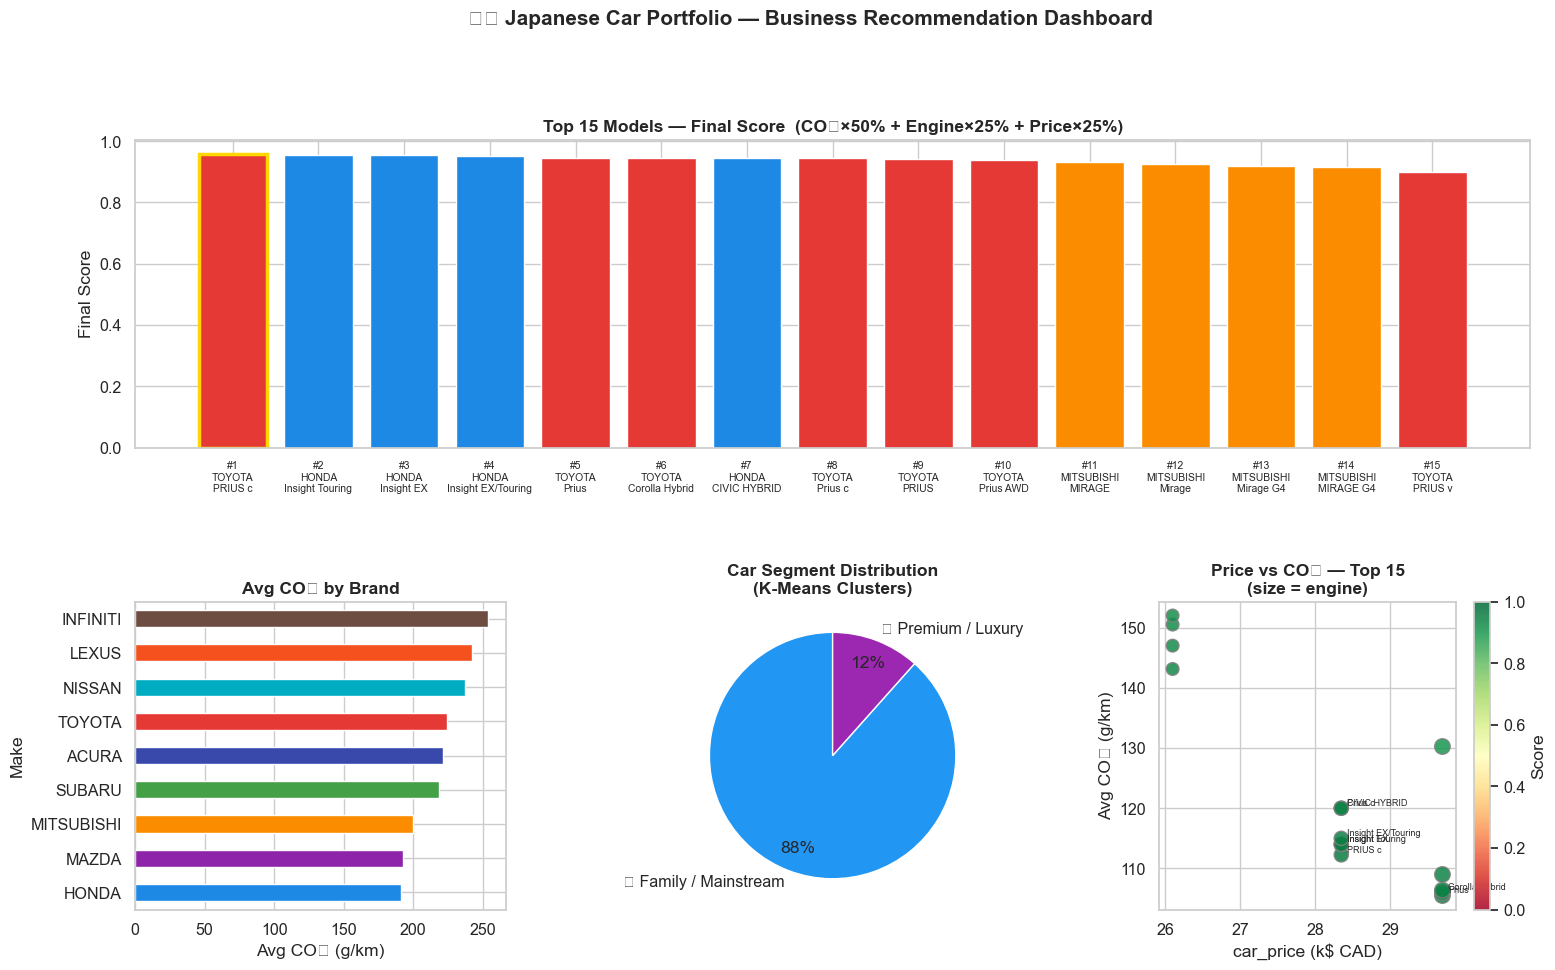

✅ Dashboard saved → japanese_cars_dashboard.png


In [42]:
# ── Cell 34: Executive summary dashboard ──────────────────────────────────────

fig = plt.figure(figsize=(18, 10))
fig.suptitle('🇯🇵 Japanese Car Portfolio — Business Recommendation Dashboard',
             fontsize=15, fontweight='bold', y=1.01)

from matplotlib.gridspec import GridSpec
gs = GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.38)

top15 = model_scores.head(15)

# 1. Top 15 bar (full width top row)
ax1 = fig.add_subplot(gs[0, :])
bar_c = [BRAND_COLORS.get(m, '#9E9E9E') for m in top15['Make']]
bars  = ax1.bar(range(len(top15)), top15['Final_Score'],
                color=bar_c, edgecolor='white')
bars[0].set_edgecolor('gold'); bars[0].set_linewidth(2.5)
ax1.set_xticks(range(len(top15)))
ax1.set_xticklabels(
    [f"#{i+1}\n{r['Make']}\n{r['Model']}" for i, r in top15.iterrows()],
    fontsize=7.5
)
ax1.set_title('Top 15 Models — Final Score  (CO₂×50% + Engine×25% + Price×25%)',
              fontweight='bold')
ax1.set_ylabel('Final Score')

# 2. Avg CO₂ by brand
ax2 = fig.add_subplot(gs[1, 0])
brand_co2 = df.groupby('Make')['CO2 Emissions(g/km)'].mean().sort_values()
bc = [BRAND_COLORS.get(b,'#9E9E9E') for b in brand_co2.index]
brand_co2.plot(kind='barh', ax=ax2, color=bc, edgecolor='white')
ax2.set_title('Avg CO₂ by Brand', fontweight='bold')
ax2.set_xlabel('Avg CO₂ (g/km)')

# 3. Cluster pie
ax3 = fig.add_subplot(gs[1, 1])
cl_counts = df_cl['Cluster_Name'].value_counts()
cl_counts.plot(kind='pie', ax=ax3,
               colors=[CLUSTER_PALETTE.get(k,'#9E9E9E') for k in cl_counts.index],
               autopct='%1.0f%%', startangle=90, pctdistance=0.8)
ax3.set_title('Car Segment Distribution\n(K-Means Clusters)', fontweight='bold')
ax3.set_ylabel('')

# 4. Scatter top 15: price vs CO2
ax4 = fig.add_subplot(gs[1, 2])
sc = ax4.scatter(top15['Price_mean']/1000, top15['CO2_mean'],
                 s=top15['Engine_mean']*70,
                 c=top15['Final_Score'], cmap='RdYlGn',
                 alpha=0.85, edgecolors='grey', vmin=0, vmax=1)
plt.colorbar(sc, ax=ax4, label='Score')
for _, row in top15.head(8).iterrows():
    ax4.annotate(row['Model'], (row['Price_mean']/1000, row['CO2_mean']),
                 textcoords='offset points', xytext=(4, 2), fontsize=6.5)
ax4.set_title('Price vs CO₂ — Top 15\n(size = engine)', fontweight='bold')
ax4.set_xlabel('car_price (k$ CAD)'); ax4.set_ylabel('Avg CO₂ (g/km)')

plt.savefig('japanese_cars_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard saved → japanese_cars_dashboard.png')

In [43]:
# ── Cell 35: Full business conclusions ────────────────────────────────────────

top3  = model_scores.head(3)
worst3 = model_scores.nsmallest(3, 'Final_Score')

print('=' * 65)
print('EXECUTIVE SUMMARY — JAPANESE CAR ANALYSIS')
print('=' * 65)
print()
print('📊 DATASET')
print(f'  {len(df):,} car variants | 9 brands | {df["Model"].nunique()} unique models')
print(f'  3 sources: CO₂ emissions + demand model + car_price (Rev/Demand)')
print()
print('🔑 KEY FINDINGS FROM EDA')
print('  1. Mean CO₂ = 221 g/km — hybrids are 50–100 g/km below this')
print('  2. Engine size is the #1 driver of CO₂ (r = 0.84)')
print('  3. CVT transmission achieves the lowest median CO₂ of all trans. types')
print('  4. Van/Truck class emits 2× more CO₂ than City/Mini class')
print()
print('🔵 4 MARKET CLUSTERS IDENTIFIED')
for name, color in CLUSTER_PALETTE.items():
    n = (df_cl['Cluster_Name'] == name).sum()
    print(f'  {name:<30} {n:>4} variants ({n/len(df_cl)*100:.0f}%)')
print()
print('🤖 MODEL PERFORMANCE (predicting CO₂)')
for name, r in results.items():
    print(f'  {name:<25} R²={r["R²"]:.3f}  RMSE={r["RMSE (g/km)"]:.1f} g/km  CV_R²={r["CV R²"]:.3f}')
print()
print('🏆 TOP 3 RECOMMENDED MODELS')
for _, row in top3.iterrows():
    print(f'  #{int(row["Rank"])}  {row["Make"]} {row["Model"]:<30}'
          f'  CO₂={row["CO2_mean"]:.0f}  Engine={row["Engine_mean"]:.1f}L'
          f'  Price=${row["Price_mean"]:,.0f}  Score={row["Final_Score"]:.3f}')
print()
print('❌ BOTTOM 3 (AVOID for CO₂ targets)')
for _, row in worst3.iterrows():
    print(f'  #{int(row["Rank"])}  {row["Make"]} {row["Model"]:<30}'
          f'  CO₂={row["CO2_mean"]:.0f}  Engine={row["Engine_mean"]:.1f}L'
          f'  Price=${row["Price_mean"]:,.0f}  Score={row["Final_Score"]:.3f}')
print()
print('💡 STRATEGIC RECOMMENDATIONS')
print('  ✅ Prioritise HYBRID models — they cut CO₂ by ~50% vs petrol equivalents')
print('  ✅ Focus on Compact and Mid-size classes — best balance of volume and CO₂')
print('  ✅ CVT transmission models deliver consistently lower CO₂ — prefer them')
print('  ⚠️  Avoid full-size trucks/SUVs with V8 engines for any eco-focused strategy')
print('=' * 65)

EXECUTIVE SUMMARY — JAPANESE CAR ANALYSIS

📊 DATASET
  1,239 car variants | 9 brands | 384 unique models
  3 sources: CO₂ emissions + demand model + car_price (Rev/Demand)

🔑 KEY FINDINGS FROM EDA
  1. Mean CO₂ = 221 g/km — hybrids are 50–100 g/km below this
  2. Engine size is the #1 driver of CO₂ (r = 0.84)
  3. CVT transmission achieves the lowest median CO₂ of all trans. types
  4. Van/Truck class emits 2× more CO₂ than City/Mini class

🔵 4 MARKET CLUSTERS IDENTIFIED
  🟢 Eco / Hybrid                    0 variants (0%)
  🚗 Family / Mainstream           931 variants (88%)
  🏎️  Sport / Large                 0 variants (0%)
  💎 Premium / Luxury              122 variants (12%)

🤖 MODEL PERFORMANCE (predicting CO₂)
  Linear Regression         R²=0.803  RMSE=23.7 g/km  CV_R²=0.795
  Random Forest             R²=0.879  RMSE=18.6 g/km  CV_R²=0.869
  Gradient Boosting         R²=0.904  RMSE=16.5 g/km  CV_R²=0.871

🏆 TOP 3 RECOMMENDED MODELS
  #1  TOYOTA PRIUS c                         CO₂=1